# Switching-listener analysis

Four studies, one shared observation stream per simulation index, `n=1, m=7`,
θ\* ∈ {0.1…0.9}, ψ\* ∈ {honest, pers+, pers−}, α ∈ {1, 1.5, 2, 3, 4, 5, 7, 10},
c ∈ {2, 3, 3.5, 4, 5}, switch ∈ {hard, soft}, 100 sims × 150 rounds.

| study | speaker | audience | mode |
|---|---|---|---|
| **A** | S1 | switching L1 | offline (listener cannot influence the speaker) |
| **B** | S2 modelling an exact replica of the switching L1 | switching L1 | feedback |
| **Fvig** | S2 modelling a vigilant L1 | vigilant L1 | offline — Fang's strategic dyad at level 2 |
| **Fcred** | S2 modelling a credulous L1 | credulous L1 | offline — Fang's cooperative dyad at level 2 |

Each dataset records three listeners every round: always-**cred**ulous,
always-**vig**ilant, and the **switch**ing one. In A/Fvig/Fcred the speaker is
blind to the listener, so all three see the same stream. In B the stream is the
one S2 produced *for the switching listener*; `cred`/`vig` are counterfactual
listeners on that stream.

**Where the numbers come from.** Figures read the aggregate tables in
`results/switching/agg/` (built by `experiments/switching/aggregate.py`, ~1 min).
`rounds`/`aligned` are per-cell means and SDs — paired differences are formed
per simulation *before* averaging, so their CIs are valid. `runs` and
`tau_summary` are per-simulation, so τ distributions and run-level spreads are
exact. `load_cell()` at the bottom of §0 pulls raw rows for any deep dive.

## 0. Setup

In [1]:
import json, os, sys, glob, itertools
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
AGG_DIR = os.path.join(ROOT, "results", "switching", "agg")
RAW_DIR = os.path.join(ROOT, "results")
FIG_DIR = os.path.join(ROOT, "results", "switching", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

SAVE = True           # True  -> every figure also written to FIG_DIR as png

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.figsize": (11, 6), "figure.dpi": 110, "savefig.dpi": 160,
    "savefig.bbox": "tight", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})
print("ROOT:", ROOT)

ROOT: C:\Users\onerk\argumentative-awareness


In [2]:
# ---- load the aggregate tables -------------------------------------------
def _load(name):
    return pd.read_parquet(os.path.join(AGG_DIR, f"{name}.parquet"))

RD  = _load("rounds")          # per (study, theta*, psi*, alpha, c, switch_type, round)
AL  = _load("aligned")         # same, indexed by k = round - tau
RU  = _load("runs")            # per simulation, at fixed horizons and at tau
UT  = _load("utterances")      # utterance frequencies
EV  = _load("evasion")         # B only: by margin-to-boundary bin
EVR = _load("evasion_rounds")  # B only: by round
META = json.load(open(os.path.join(AGG_DIR, "meta.json"), encoding="utf-8"))

STUDIES = ["A", "B", "Fvig", "Fcred"]
TAU = pd.concat(
    [pd.read_parquet(os.path.join(RAW_DIR, f"switching_{s}", "tau_summary.parquet"))
     for s in STUDIES], ignore_index=True)

for nm, df in [("rounds", RD), ("aligned", AL), ("runs", RU), ("tau", TAU)]:
    print(f"{nm:8s} {len(df):>10,} rows")

rounds    1,296,000 rows
aligned     701,607 rows
runs      4,566,745 rows
tau         864,000 rows


In [3]:
# ---- constants, labels, palette ------------------------------------------
THETAS = sorted(RD.theta_star.unique())
ALPHAS = sorted(RD.alpha.unique())
CS     = sorted(RD.c.unique())
SWITCH = ["hard", "soft"]
PSIS   = ["inf", "high", "low"]
T_MAX  = int(RD["round"].max())

PSI_LABEL   = {"inf": "honest", "high": "pers+", "low": "pers−"}
STUDY_LABEL = {"A": "A: S1 speaker", "B": "B: S2 ↔ switching L1",
               "Fvig": "Fvig: S2 ↔ vigilant L1", "Fcred": "Fcred: S2 ↔ credulous L1"}
LISTENER_LABEL = {"cred": "credulous", "vig": "vigilant", "switch": "switching"}

COL = {"cred": "#d1751f", "vig": "#2b6cb0", "switch": "#2f8f4e",
       "hard": "#2f8f4e", "soft": "#7a4bbf",
       "A": "#888888", "B": "#2f8f4e", "Fvig": "#2b6cb0", "Fcred": "#d1751f"}
PSI_LS = {"inf": "-", "high": "--", "low": ":"}
CMAP_SEQ, CMAP_DIV = "viridis", "RdBu_r"

def alpha_colors(alphas=ALPHAS, cmap="plasma"):
    cm = plt.get_cmap(cmap)
    return {a: cm(i / max(len(alphas) - 1, 1) * 0.85) for i, a in enumerate(alphas)}

def theta_colors(thetas=THETAS, cmap="viridis"):
    cm = plt.get_cmap(cmap)
    return {t: cm(i / max(len(thetas) - 1, 1) * 0.9) for i, t in enumerate(thetas)}

def c_colors(cs=CS, cmap="cividis"):
    cm = plt.get_cmap(cmap)
    return {c: cm(i / max(len(cs) - 1, 1) * 0.85) for i, c in enumerate(cs)}

ACOL, TCOL, CCOL = alpha_colors(), theta_colors(), c_colors()

# Defaults used wherever a single configuration has to be picked.  Change and
# re-run any cell below to re-aim a figure.
FOCUS = dict(theta=0.3, alpha=3.0, c=3.5, switch_type="hard")
print("grid:", len(THETAS), "theta x", len(ALPHAS), "alpha x", len(CS), "c x", len(SWITCH), "switch")
print("FOCUS:", FOCUS)

grid: 9 theta x 8 alpha x 5 c x 2 switch
FOCUS: {'theta': 0.3, 'alpha': 3.0, 'c': 3.5, 'switch_type': 'hard'}


In [4]:
# ---- selection / plotting helpers ----------------------------------------
def sel(df, **kw):
    '''Filter by equality, or by membership when the value is a list/tuple.'''
    m = np.ones(len(df), dtype=bool)
    for k, v in kw.items():
        if v is None:
            continue
        col = df[k].to_numpy()
        m &= np.isin(col, list(v)) if isinstance(v, (list, tuple, set, np.ndarray)) else (col == v)
    return df[m]

def finish(ax, ttl="", xlabel="", ylabel="", legend=True, save_as=None, **lg):
    '''Set labels, draw the legend (extra kwargs go to it) and optionally save.'''
    ax.set_title(ttl); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if legend and (ax.get_legend_handles_labels()[0]):
        ax.legend(**lg)
    fig = ax.get_figure(); fig.tight_layout()
    if SAVE and save_as:
        fig.savefig(os.path.join(FIG_DIR, f"{save_as}.png"))
    return ax

def band(ax, x, mu, sd, n, color, label=None, z=1.96, **kw):
    '''Mean line with a +/- z * SEM ribbon.'''
    mu, sd, n = np.asarray(mu, float), np.asarray(sd, float), np.asarray(n, float)
    ax.plot(x, mu, color=color, label=label, **kw)
    sem = sd / np.sqrt(np.maximum(n, 1))
    ax.fill_between(x, mu - z * sem, mu + z * sem, color=color, alpha=0.18, lw=0)

def heat(ax, M, xticks, yticks, xlabel, ylabel, title, cmap=CMAP_SEQ,
         vmin=None, vmax=None, fmt="{:.2f}", cbar_label="", txt_thresh=0.55):
    im = ax.imshow(M, cmap=cmap, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(xticks)), [str(t) for t in xticks])
    ax.set_yticks(range(len(yticks)), [str(t) for t in yticks])
    ax.grid(False)
    lo = np.nanmin(M) if vmin is None else vmin
    hi = np.nanmax(M) if vmax is None else vmax
    rng = (hi - lo) or 1.0
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isfinite(v):
                shade = abs(v - lo) / rng
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8.5,
                        color="white" if shade > txt_thresh else "black")
    cb = ax.get_figure().colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    if cbar_label:
        cb.set_label(cbar_label)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    return im

def pivot(df, index, columns, values, **kw):
    d = sel(df, **kw)
    return d.pivot_table(index=index, columns=columns, values=values, aggfunc="mean")

In [5]:
# ---- detection-rate helpers (exact: computed from per-run tau) ------------
def hit(df, horizon=None):
    '''Did the run switch (by `horizon`, if given)?'''
    if horizon is None:
        return (df["tau"] > 0).astype(float)
    return ((df["tau"] > 0) & (df["tau"] <= horizon)).astype(float)

def rate_by(keys, horizon=None, **kw):
    t = sel(TAU, **kw).copy()
    t["hit"] = hit(t, horizon)
    return t.groupby(keys, observed=True)["hit"].mean().reset_index(name="rate")

def survival(tau_series, T=None):
    '''P(not yet switched by t) for t = 0..T, from per-run tau.'''
    T = T or T_MAX
    tv = np.asarray(tau_series)
    n = len(tv)
    fired = tv[tv > 0].astype(int)
    cnt = np.bincount(fired, minlength=T + 2)[:T + 1]
    return 1.0 - np.cumsum(cnt) / max(n, 1)

def power_fa(study="B", horizon=None, **kw):
    '''False-alarm rate (honest speaker) and power (mean of pers+/pers-).'''
    t = sel(TAU, study=study, **kw).copy()
    t["hit"] = hit(t, horizon)
    fa = t[t.psi_star == "inf"]["hit"].mean()
    pw = t[t.psi_star != "inf"]["hit"].mean()
    return fa, pw

# ---- raw-row access for deep dives ---------------------------------------
def load_cell(study, theta_star, psi_star, alpha, c=None, switch_type=None, columns=None):
    '''Raw per-round rows for one cell (or one condition inside it).'''
    cfg = json.load(open(os.path.join(RAW_DIR, f"switching_{study}", "run_config.json"), encoding="utf-8"))
    cells = [x for x in cfg["cells"]
             if x["theta_star"] == theta_star and x["psi_star"] == psi_star and x["alpha"] == alpha]
    if cfg["mode"] == "feedback":
        cells = [x for x in cells
                 if (c is None or x["c"] == c) and (switch_type is None or x["switch_type"] == switch_type)]
    if not cells:
        raise ValueError(f"no cell for {study} theta*={theta_star} psi*={psi_star} alpha={alpha}")
    df = pd.concat([pd.read_parquet(
        os.path.join(RAW_DIR, f"switching_{study}", "trajectories", f"cell={x['cell_id']:04d}", "part.parquet"),
        columns=columns) for x in cells], ignore_index=True)
    if cfg["mode"] == "offline":
        if c is not None:
            df = df[df.c == c]
        if switch_type is not None:
            df = df[df.switch_type == switch_type]
    return df.reset_index(drop=True)

print("helpers ready")

helpers ready


## 1. Diagnostics

Before reading anything into the results: is every cell present, are the
streams paired as intended, and does the detector behave like its own null
says it should?

In [6]:
# 1.1 completeness
rows = []
for s in STUDIES:
    cfg = json.load(open(os.path.join(RAW_DIR, f"switching_{s}", "run_config.json"), encoding="utf-8"))
    r, t = sel(RD, study=s), sel(TAU, study=s)
    shards = len(glob.glob(os.path.join(RAW_DIR, f"switching_{s}", "trajectories", "cell=*", "part.parquet")))
    rows.append(dict(study=s, status=cfg["status"], wall_min=round(cfg["wall_seconds"] / 60, 1),
                     cells=cfg["grid"]["n_cells"], shards=shards, tau_rows=len(t),
                     conditions=len(r.groupby(["theta_star", "psi_star", "alpha", "c", "switch_type"])),
                     min_n=int(r.n.min()), max_n=int(r.n.max()),
                     rounds=int(r["round"].max()), git=cfg["git_hash"][:7]))
comp = pd.DataFrame(rows)
display(comp)
assert (comp.status == "complete").all(), "a study did not finish"
assert (comp.cells == comp.shards).all(), "missing shard"
assert (comp.min_n == 100).all() and (comp.max_n == 100).all(), "unexpected simulation count"
print("OK: all four studies complete, every cell present, 100 sims everywhere")

,study,status,wall_min,cells,shards,tau_rows,conditions,min_n,max_n,rounds,git
0,A,complete,32.3,216,216,216000,2160,100,100,150,99c2523
1,B,complete,458.5,2160,2160,216000,2160,100,100,150,99c2523
2,Fvig,complete,35.5,216,216,216000,2160,100,100,150,99c2523
3,Fcred,complete,45.9,216,216,216000,2160,100,100,150,99c2523


OK: all four studies complete, every cell present, 100 sims everywhere


In [7]:
# 1.2 paired observation streams: sim i must see identical observations in
# every study and every condition at the same theta*
def obs_stream(study, theta, psi, alpha, sim=3, **kw):
    d = load_cell(study, theta, psi, alpha, columns=["sim", "round", "obs", "c", "switch_type"], **kw)
    d = d[(d.sim == sim) & (d.c == d.c.iloc[0]) & (d.switch_type == d.switch_type.iloc[0])]
    return d.sort_values("round").obs.to_numpy()

ref = obs_stream("A", 0.3, "inf", 3.0)
checks = {
    "A vs Fvig":        np.array_equal(ref, obs_stream("Fvig", 0.3, "inf", 3.0)),
    "A vs Fcred":       np.array_equal(ref, obs_stream("Fcred", 0.3, "inf", 3.0)),
    "A vs B":           np.array_equal(ref, obs_stream("B", 0.3, "inf", 3.0, c=3.5, switch_type="hard")),
    "A: psi* invariant":  np.array_equal(ref, obs_stream("A", 0.3, "high", 3.0)),
    "A: alpha invariant": np.array_equal(ref, obs_stream("A", 0.3, "inf", 10.0)),
    "different at other theta*": not np.array_equal(ref, obs_stream("A", 0.7, "inf", 3.0)),
}
for k, v in checks.items():
    print(("OK  " if v else "BAD ") + k)
assert all(checks.values())

OK  A vs Fvig
OK  A vs Fcred
OK  A vs B
OK  A: psi* invariant
OK  A: alpha invariant
OK  different at other theta*


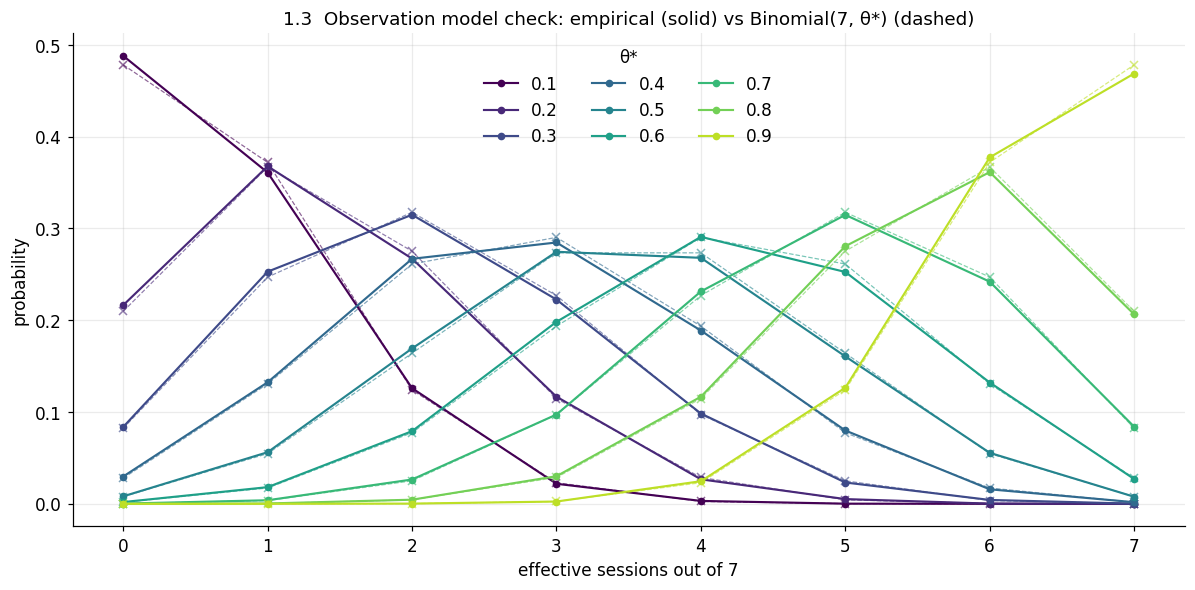

In [8]:
# 1.3 the world: observed effective-session counts must follow Binomial(7, theta*)
from scipy.stats import binom
fig, ax = plt.subplots(figsize=(11, 5.5))
u = sel(UT, study="A", alpha=3.0, psi_star="inf")
for th in THETAS:
    d = u[u.theta_star == th].groupby("obs_count")["n"].sum()
    p = (d / d.sum()).reindex(range(8), fill_value=0)
    ax.plot(range(8), p.values, "o-", color=TCOL[th], ms=4, lw=1.4, label=f"{th:g}")
    ax.plot(range(8), binom.pmf(range(8), 7, th), "x--", color=TCOL[th], ms=5, lw=0.8, alpha=0.6)
finish(ax, "1.3  Observation model check: empirical (solid) vs Binomial(7, θ*) (dashed)",
       "effective sessions out of 7", "probability", ncol=3, title="θ*", save_as="D1_world_check")
plt.show()

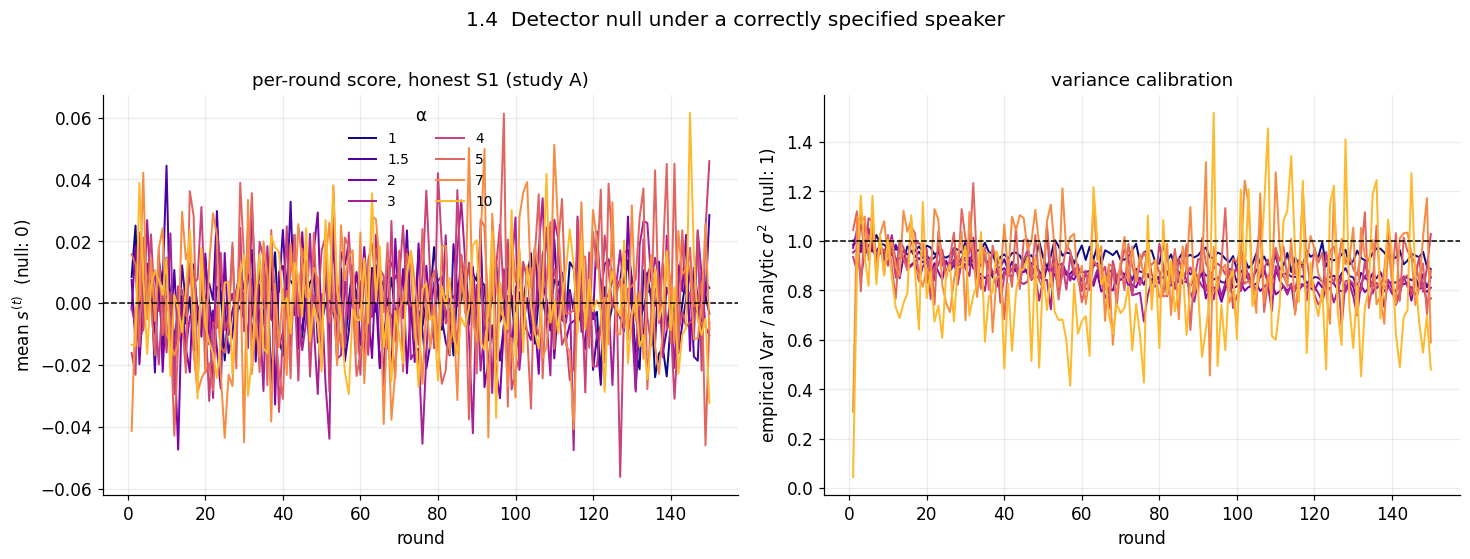

mean |score| over all rounds/alphas, honest S1: 0.03586 | pooled Var/sigma^2: 1.005


In [9]:
# 1.4 detector null. Under study A's honest S1 the speaker *is* the model, so
# the per-round score should average 0 and its empirical variance should match
# the analytic sigma^2 the test accumulates.
d = sel(RD, study="A", psi_star="inf", c=CS[0], switch_type="hard")
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for a in ALPHAS:
    q = d[d.alpha == a].groupby("round")[["sus1_score", "sus1_score_sd", "sus1_sigma2", "n"]].mean()
    axes[0].plot(q.index, q.sus1_score, color=ACOL[a], lw=1.3, label=f"{a:g}")
    axes[1].plot(q.index, q.sus1_score_sd ** 2 / q.sus1_sigma2, color=ACOL[a], lw=1.3, label=f"{a:g}")
axes[0].axhline(0, color="k", lw=1, ls="--")
axes[1].axhline(1, color="k", lw=1, ls="--")
finish(axes[0], "per-round score, honest S1 (study A)", "round", "mean $s^{(t)}$  (null: 0)",
       ncol=2, title="α", fontsize=9)
finish(axes[1], "variance calibration", "round", "empirical Var / analytic $\\sigma^2$  (null: 1)", legend=False)
fig.suptitle("1.4  Detector null under a correctly specified speaker", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "D2_null_calibration.png"))
plt.show()

print("mean |score| over all rounds/alphas, honest S1:",
      float(d.sus1_score.abs().mean()).__round__(5),
      "| pooled Var/sigma^2:", float((d.sus1_score_sd ** 2 / d.sus1_sigma2).mean()).__round__(3))

In [10]:
# 1.5 bookkeeping invariants
b = sel(RD, study="B")
print("B: replica never diverged      ->", float(sel(TAU, study='B').replica_maxdiff.max()) == 0.0)
# in the offline studies hard and soft share the stream, so tau must agree
tA = sel(TAU, study="A")
p = tA.pivot_table(index=["theta_star", "psi_star", "alpha", "c", "sim"], columns="switch_type", values="tau")
print("A: hard/soft share tau         ->", bool((p["hard"] == p["soft"]).all()))
# in B they need not: the speaker reacts to the switch type
pB = sel(TAU, study="B").pivot_table(index=["theta_star", "psi_star", "alpha", "c", "sim"],
                                     columns="switch_type", values="tau")
print("B: hard/soft tau differ in", f"{float((pB['hard'] != pB['soft']).mean()):.1%}", "of runs (expected > 0)")
# switching listener == credulous before tau, by construction
chk = sel(RD, study="A", psi_star="high", alpha=3.0, c=3.5, switch_type="hard", theta_star=0.3)
print("A: |bias_switch - bias_cred| at round 1 =", float((chk[chk['round'] == 1].bias_switch -
                                                         chk[chk['round'] == 1].bias_cred).abs().max()))

B: replica never diverged      -> True
A: hard/soft share tau         -> True
B: hard/soft tau differ in 64.3% of runs (expected > 0)
A: |bias_switch - bias_cred| at round 1 = 0.0


## 2. Detection: what the test can and cannot do

The detector's null hypothesis is *"my interlocutor is an S1 that is trying to
be informative"*. In study A that is literally true of the honest speaker, so
alarms there are genuine false positives at the nominal rate. In B the honest
speaker is an **S2** — a different speaker — so an "honest-speaker alarm" is
really a *level*-mismatch detection. Both are reported as `false alarm` below;
the distinction is the subject of §3.

In [11]:
# 2.1 headline: false alarms vs power, pooled over theta*
tab = []
for s in ["A", "B"]:
    for a in ALPHAS:
        for c in CS:
            fa, pw = power_fa(study=s, alpha=a, c=c)
            tab.append(dict(study=s, alpha=a, c=c, false_alarm=fa, power=pw, youden=pw - fa))
OC = pd.DataFrame(tab)
print("Study B - false-alarm rate (honest S2) by alpha x c")
display(OC[OC.study == "B"].pivot(index="alpha", columns="c", values="false_alarm").round(3))
print("Study B - power (persuasive S2)")
display(OC[OC.study == "B"].pivot(index="alpha", columns="c", values="power").round(3))
print("Study A - false-alarm rate (honest S1): the nominal behaviour")
display(OC[OC.study == "A"].pivot(index="alpha", columns="c", values="false_alarm").round(3))

Study B - false-alarm rate (honest S2) by alpha x c


c,2.0,3.0,3.5,4.0,5.0
alpha,,,,,
1.0,0.166,0.009,0.000,0.000,0.000
1.5,0.247,0.034,0.009,0.002,0.000
2.0,0.418,0.107,0.051,0.017,0.003
3.0,0.801,0.598,0.453,0.317,0.122
4.0,0.909,0.820,0.769,0.706,0.591
5.0,0.956,0.912,0.871,0.839,0.736
7.0,0.972,0.962,0.951,0.927,0.894
10.0,0.917,0.911,0.901,0.905,0.899


Study B - power (persuasive S2)


c,2.0,3.0,3.5,4.0,5.0
alpha,,,,,
1.0,0.971,0.766,0.563,0.337,0.063
1.5,0.991,0.910,0.819,0.686,0.387
2.0,0.989,0.922,0.850,0.764,0.583
3.0,0.989,0.945,0.902,0.857,0.731
4.0,0.997,0.980,0.964,0.937,0.858
5.0,0.999,0.995,0.988,0.978,0.936
7.0,1.000,0.999,0.999,0.999,0.993
10.0,1.000,1.000,1.000,1.000,1.000


Study A - false-alarm rate (honest S1): the nominal behaviour


c,2.0,3.0,3.5,4.0,5.0
alpha,,,,,
1.0,0.166,0.009,0.000,0.000,0.000
1.5,0.173,0.012,0.002,0.000,0.000
2.0,0.207,0.019,0.006,0.001,0.000
3.0,0.170,0.021,0.007,0.003,0.000
4.0,0.236,0.032,0.018,0.008,0.000
5.0,0.226,0.106,0.082,0.011,0.006
7.0,0.194,0.066,0.036,0.029,0.014
10.0,0.234,0.099,0.053,0.033,0.010


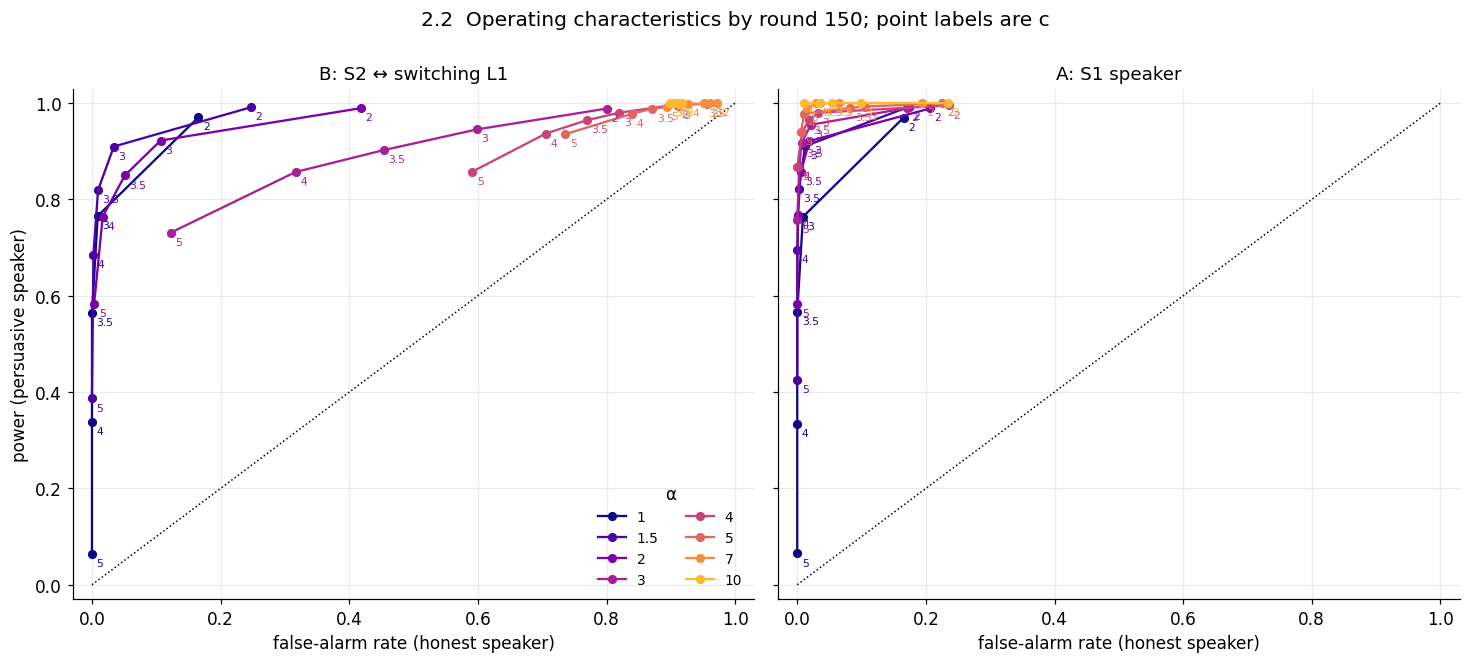

In [12]:
# 2.2 ROC-style: each line is one alpha, traced through the five boundaries c
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), sharex=True, sharey=True)
for ax, s in zip(axes, ["B", "A"]):
    for a in ALPHAS:
        q = OC[(OC.study == s) & (OC.alpha == a)].sort_values("c")
        ax.plot(q.false_alarm, q.power, "o-", color=ACOL[a], ms=5, lw=1.5, label=f"{a:g}")
        for _, r in q.iterrows():
            ax.annotate(f"{r.c:g}", (r.false_alarm, r.power), fontsize=7,
                        xytext=(3, -8), textcoords="offset points", color=ACOL[a])
    ax.plot([0, 1], [0, 1], color="k", lw=1, ls=":")
    ax.set_title(STUDY_LABEL[s])
    ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
axes[0].legend(title="α", ncol=2, fontsize=9)
for ax in axes:
    ax.set_xlabel("false-alarm rate (honest speaker)")
axes[0].set_ylabel("power (persuasive speaker)")
fig.suptitle("2.2  Operating characteristics by round 150; point labels are c", y=1.00)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F1_roc.png"))
plt.show()

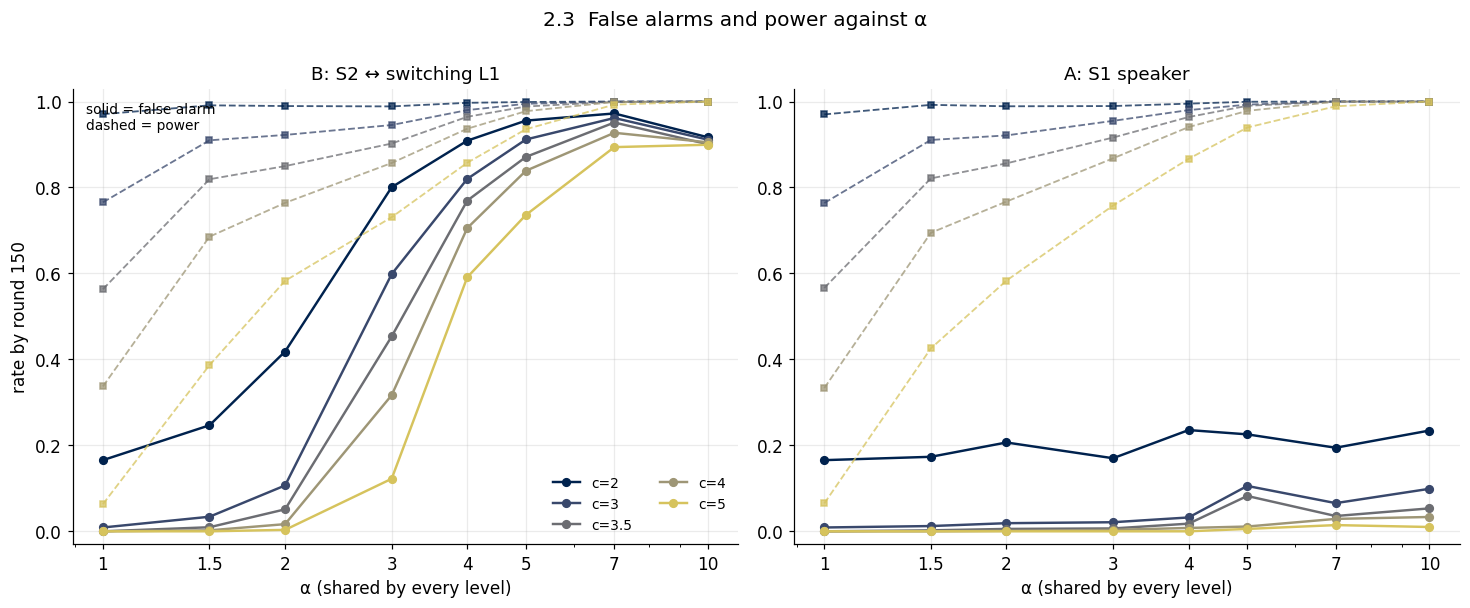

In [13]:
# 2.3 the same trade-off read against alpha, which is the variable that breaks it
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5), sharex=True)
for c in CS:
    for ax, s in zip(axes, ["B", "A"]):
        q = OC[(OC.study == s) & (OC.c == c)].sort_values("alpha")
        ax.plot(q.alpha, q.false_alarm, "o-", color=CCOL[c], lw=1.6, ms=5, label=f"c={c:g}")
        ax.plot(q.alpha, q.power, "s--", color=CCOL[c], lw=1.2, ms=4, alpha=0.75)
for ax, s in zip(axes, ["B", "A"]):
    ax.set_xscale("log"); ax.set_xticks(ALPHAS, [f"{a:g}" for a in ALPHAS])
    ax.set_ylim(-0.03, 1.03); ax.set_xlabel("α (shared by every level)")
    ax.set_title(STUDY_LABEL[s])
axes[0].set_ylabel("rate by round 150")
axes[0].legend(ncol=2, fontsize=9)
axes[0].text(0.02, 0.97, "solid = false alarm\ndashed = power", transform=axes[0].transAxes,
             va="top", fontsize=9)
fig.suptitle("2.3  False alarms and power against α", y=1.00)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F2_rates_vs_alpha.png"))
plt.show()

### 2.4 θ\* is not a nuisance parameter

Pooling over θ\* hides a strong and non-monotone dependence, so the next three
figures keep θ\* explicit.

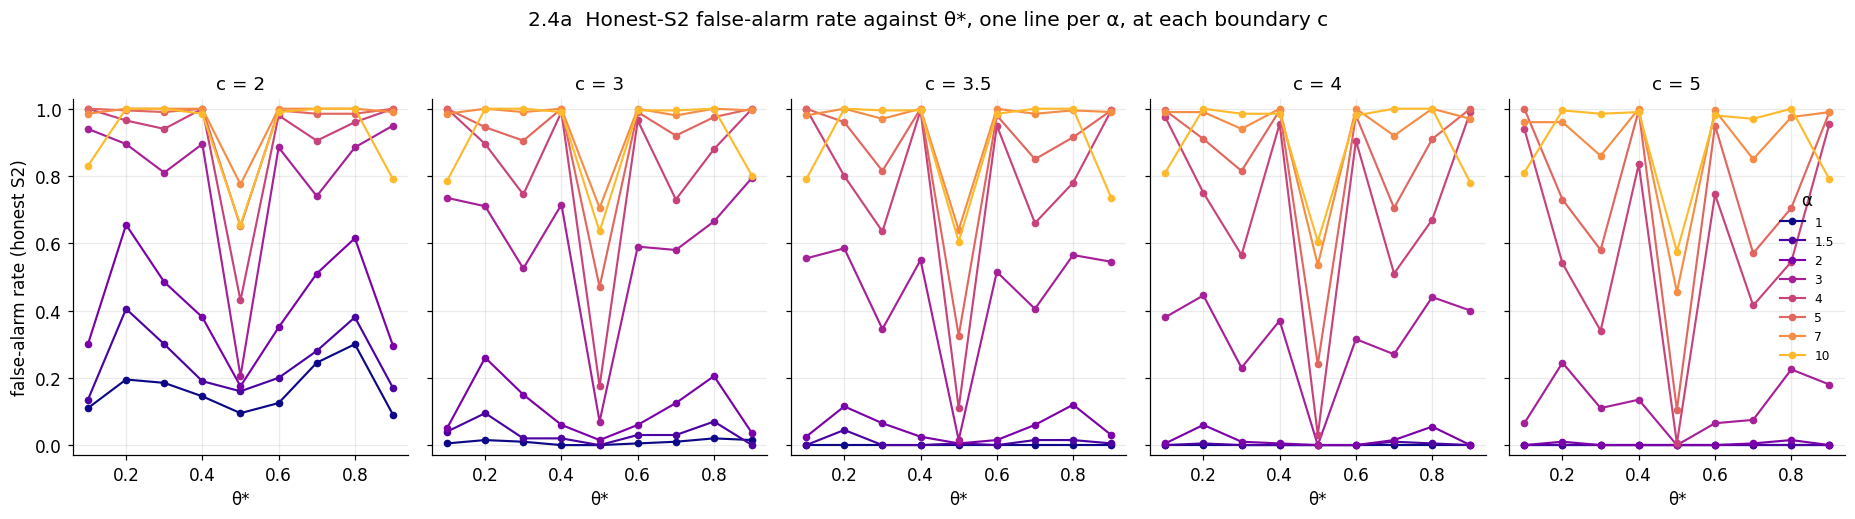

In [14]:
# 2.4a false-alarm rate against theta*, one line per alpha, at each boundary
fig, axes = plt.subplots(1, len(CS), figsize=(17, 4.6), sharey=True)
for ax, c in zip(axes, CS):
    r = rate_by(["theta_star", "alpha"], study="B", psi_star="inf", c=c)
    for a in ALPHAS:
        q = r[r.alpha == a].sort_values("theta_star")
        ax.plot(q.theta_star, q.rate, "o-", color=ACOL[a], ms=4, lw=1.4, label=f"{a:g}")
    ax.set_title(f"c = {c:g}"); ax.set_xlabel("θ*"); ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("false-alarm rate (honest S2)")
axes[-1].legend(title="α", ncol=1, fontsize=8, loc="center right")
fig.suptitle("2.4a  Honest-S2 false-alarm rate against θ*, one line per α, at each boundary c", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F3_fa_vs_theta.png"))
plt.show()

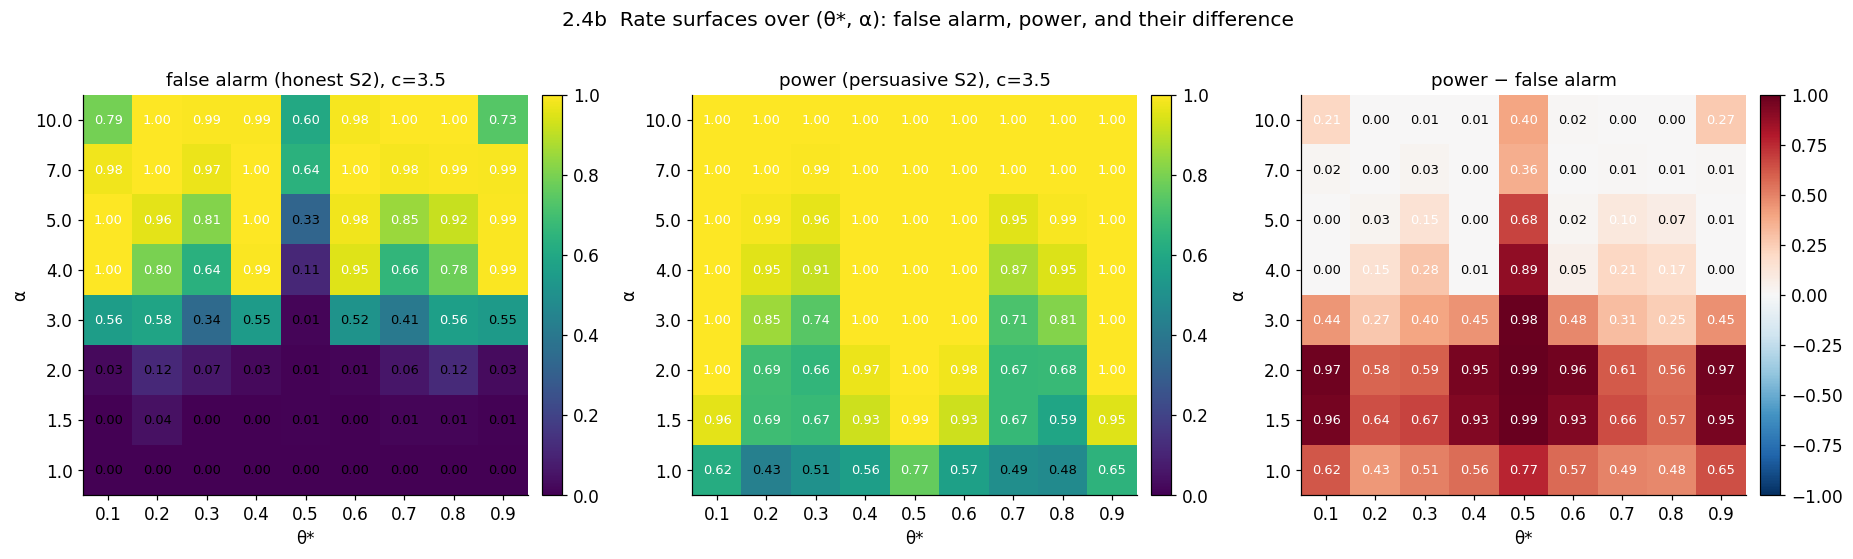

In [15]:
# 2.4b the same surface as heatmaps: honest, persuasive, and their difference
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
FA = pivot(rate_by(["theta_star", "alpha"], study="B", psi_star="inf", c=FOCUS["c"]),
           "alpha", "theta_star", "rate")
PW = pivot(rate_by(["theta_star", "alpha"], study="B", psi_star=["high", "low"], c=FOCUS["c"]),
           "alpha", "theta_star", "rate")
heat(axes[0], FA.values, FA.columns, FA.index, "θ*", "α",
     f"false alarm (honest S2), c={FOCUS['c']:g}", vmin=0, vmax=1)
heat(axes[1], PW.values, PW.columns, PW.index, "θ*", "α",
     f"power (persuasive S2), c={FOCUS['c']:g}", vmin=0, vmax=1)
heat(axes[2], (PW - FA).values, FA.columns, FA.index, "θ*", "α",
     "power − false alarm", cmap=CMAP_DIV, vmin=-1, vmax=1)
fig.suptitle("2.4b  Rate surfaces over (θ*, α): false alarm, power, and their difference", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F4_rate_heatmaps.png"))
plt.show()

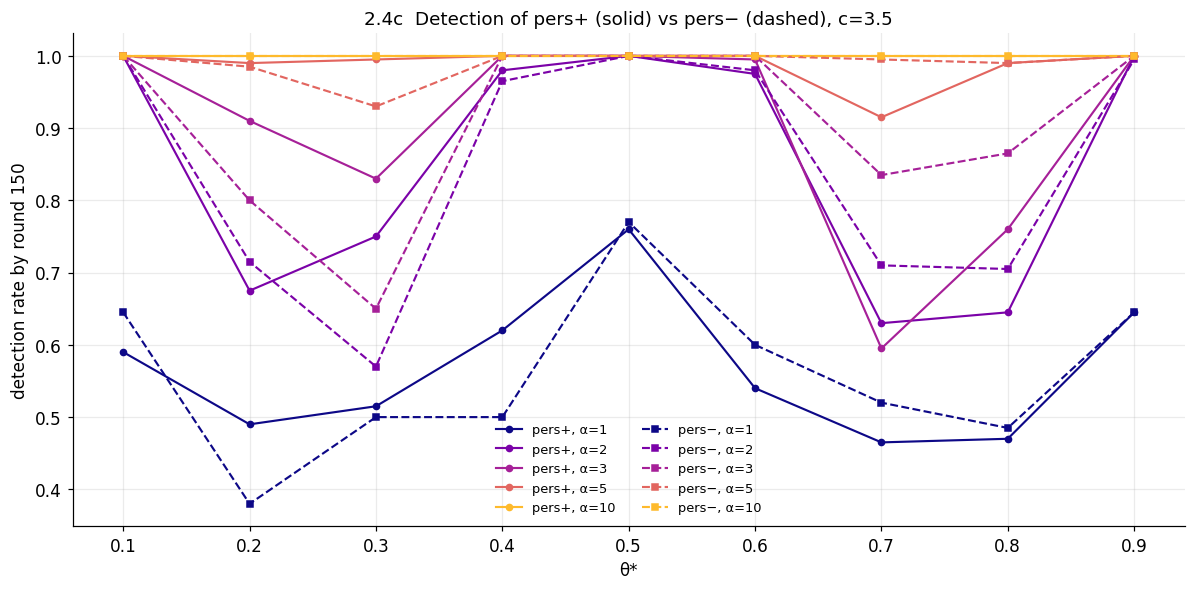

In [16]:
# 2.4c pers+ and pers- are not symmetric in theta*: a persuader has little room
# to push when theta* is already at the end it wants
fig, ax = plt.subplots(figsize=(11, 5.5))
for psi, mk in [("high", "o-"), ("low", "s--")]:
    r = rate_by(["theta_star", "alpha"], study="B", psi_star=psi, c=FOCUS["c"])
    for a in [1.0, 2.0, 3.0, 5.0, 10.0]:
        q = r[r.alpha == a].sort_values("theta_star")
        ax.plot(q.theta_star, q.rate, mk, color=ACOL[a], ms=4, lw=1.4,
                label=f"{PSI_LABEL[psi]}, α={a:g}")
finish(ax, f"2.4c  Detection of pers+ (solid) vs pers− (dashed), c={FOCUS['c']:g}",
       "θ*", "detection rate by round 150", ncol=2, fontsize=8.5, save_as="F5_pers_asymmetry")
plt.show()

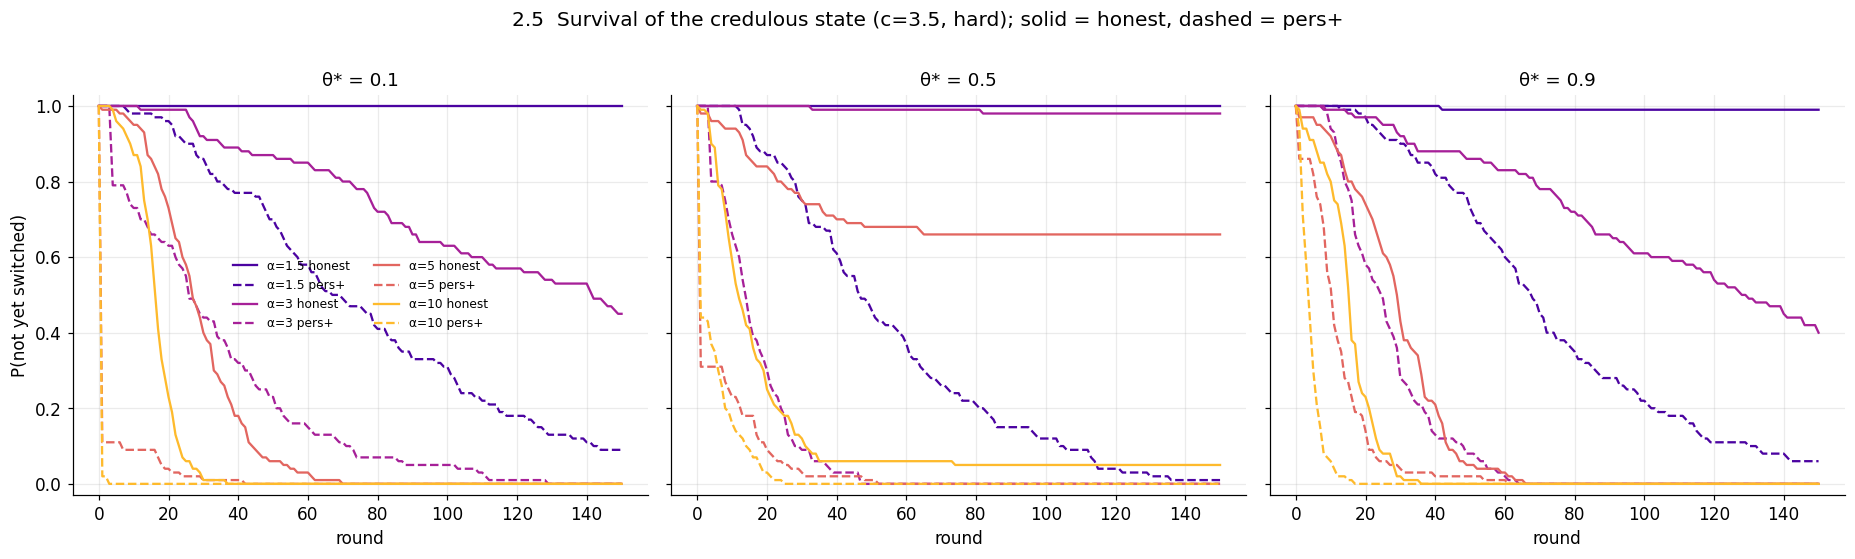

In [17]:
# 2.5 survival curves: when does the alarm fire?  Flat tail = runs that never alarm.
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
t = np.arange(T_MAX + 1)
for ax, th in zip(axes, [0.1, 0.5, 0.9]):
    for a in [1.5, 3.0, 5.0, 10.0]:
        for psi, ls in [("inf", "-"), ("high", "--")]:
            s = sel(TAU, study="B", theta_star=th, psi_star=psi, alpha=a,
                    c=FOCUS["c"], switch_type=FOCUS["switch_type"])
            ax.plot(t, survival(s.tau), ls, color=ACOL[a], lw=1.5,
                    label=f"α={a:g} {PSI_LABEL[psi]}" if ax is axes[0] else None)
    ax.set_title(f"θ* = {th:g}"); ax.set_xlabel("round"); ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("P(not yet switched)")
axes[0].legend(ncol=2, fontsize=8)
fig.suptitle(f"2.5  Survival of the credulous state (c={FOCUS['c']:g}, {FOCUS['switch_type']}); "
             "solid = honest, dashed = pers+", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F6_survival.png"))
plt.show()

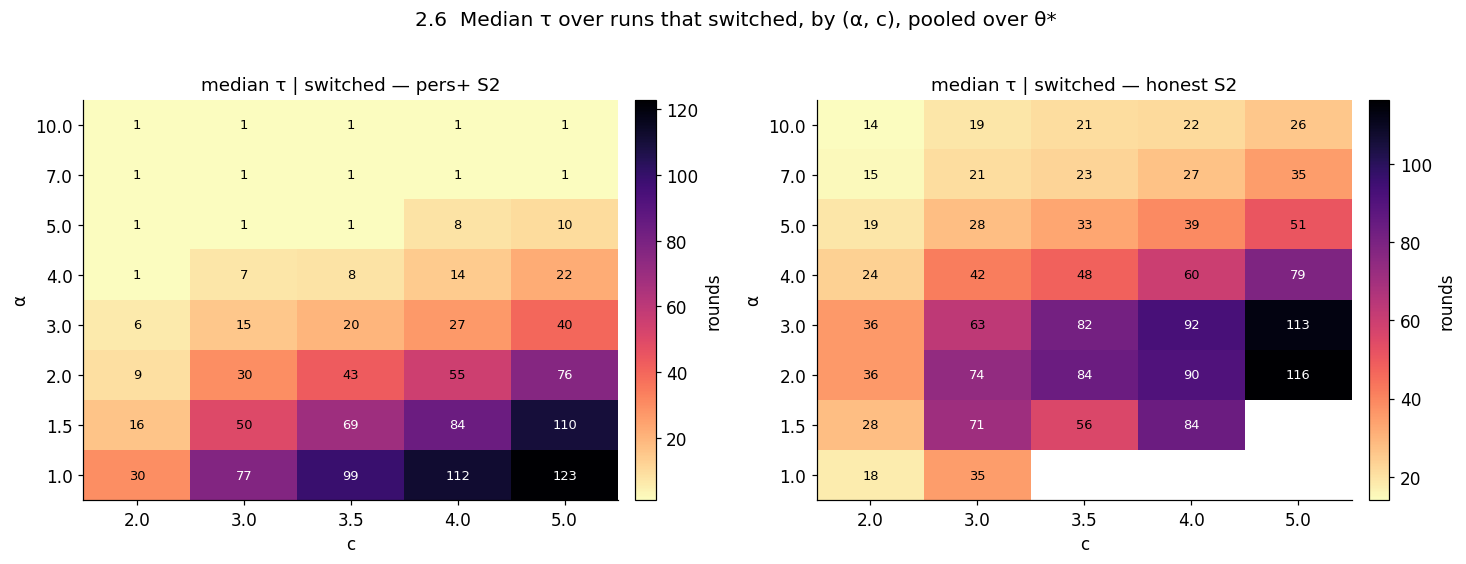

In [18]:
# 2.6 how quickly are persuaders caught?  Median tau over (alpha, c).
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, psi in zip(axes, ["high", "inf"]):
    t = sel(TAU, study="B", psi_star=psi)
    t = t[t.tau > 0]
    M = t.pivot_table(index="alpha", columns="c", values="tau", aggfunc="median")
    heat(ax, M.values, M.columns, M.index, "c", "α",
         f"median τ | switched — {PSI_LABEL[psi]} S2", cmap="magma_r",
         fmt="{:.0f}", cbar_label="rounds")
fig.suptitle("2.6  Median τ over runs that switched, by (α, c), pooled over θ*", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F7_median_tau.png"))
plt.show()

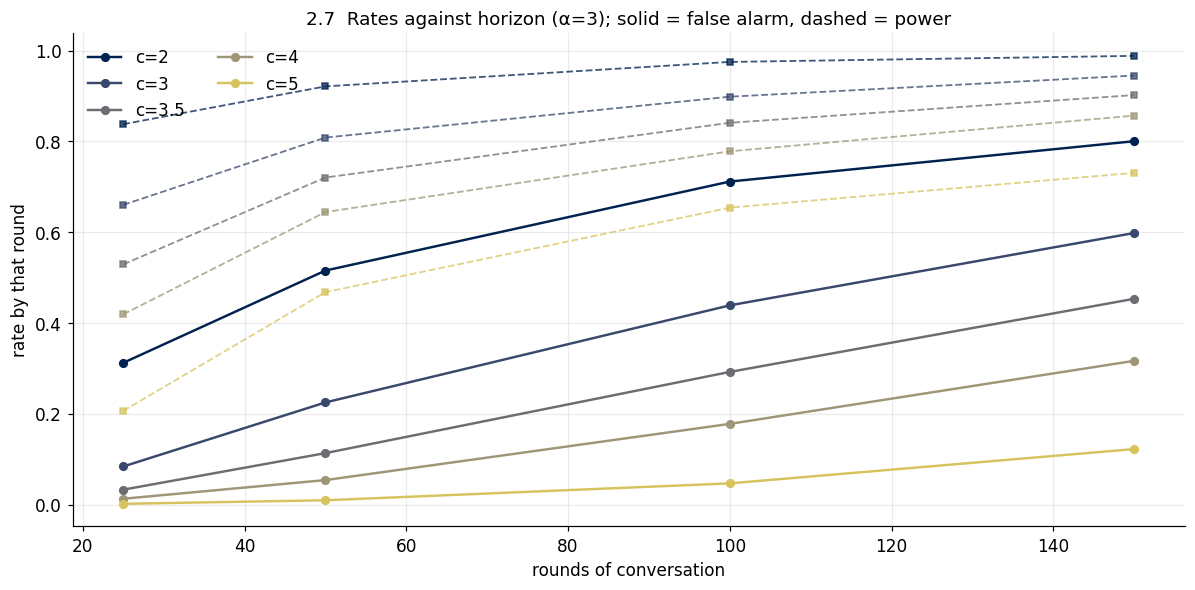

false_alarm                              power                            
c               2.0    3.0    3.5    4.0    5.0    2.0    3.0    3.5    4.0    5.0
horizon                                                                           
25            0.312  0.084  0.033  0.013  0.002  0.838  0.660  0.529  0.419  0.206
50            0.516  0.225  0.113  0.054  0.009  0.921  0.809  0.721  0.644  0.468
100           0.712  0.439  0.292  0.178  0.047  0.975  0.899  0.841  0.778  0.654
150           0.801  0.598  0.453  0.317  0.122  0.989  0.945  0.902  0.857  0.731

In [19]:
# 2.7 horizon dependence: the honest-S2 alarm keeps accumulating with time,
# so "how long do they talk" is itself a design variable
H = [25, 50, 100, 150]
fig, ax = plt.subplots(figsize=(11, 5.5))
for i, c in enumerate(CS):
    fa = [power_fa(study="B", c=c, alpha=FOCUS["alpha"], horizon=h)[0] for h in H]
    pw = [power_fa(study="B", c=c, alpha=FOCUS["alpha"], horizon=h)[1] for h in H]
    ax.plot(H, fa, "o-", color=CCOL[c], lw=1.6, ms=5, label=f"c={c:g}")
    ax.plot(H, pw, "s--", color=CCOL[c], lw=1.2, ms=4, alpha=0.75)
finish(ax, f"2.7  Rates against horizon (α={FOCUS['alpha']:g}); solid = false alarm, dashed = power",
       "rounds of conversation", "rate by that round", ncol=2, save_as="F8_horizon")
plt.show()

rows = []
for h in H:
    for c in CS:
        fa, pw = power_fa(study="B", c=c, alpha=FOCUS["alpha"], horizon=h)
        rows.append(dict(horizon=h, c=c, false_alarm=round(fa, 3), power=round(pw, 3)))
display(pd.DataFrame(rows).pivot(index="horizon", columns="c", values=["false_alarm", "power"]))

## 3. Why the honest S2 trips the detector

The statistic asks *"how surprising is this utterance under S1<sup>inf</sup>?"*.
An honest S2 is a perfectly cooperative speaker — but it optimises for a
**pragmatic** listener rather than a literal one, so it is a different
distribution over utterances. This section measures that gap directly rather
than inferring it from alarm rates.

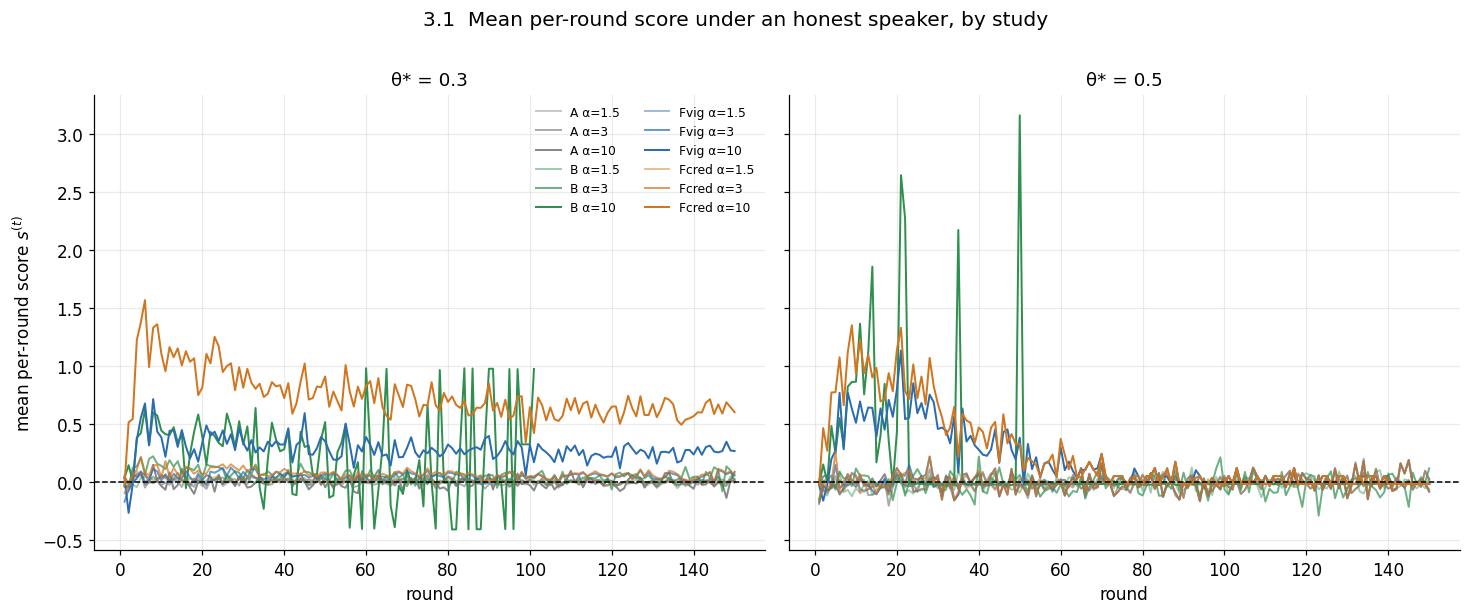

In [20]:
# 3.1 the per-round score under an honest speaker, by study.  A is the null
# (mean 0); every S2 study sits above it, and the offset grows with alpha.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5), sharey=True)
for ax, th in zip(axes, [FOCUS["theta"], 0.5]):
    for s in STUDIES:
        for a in [1.5, 3.0, 10.0]:
            q = sel(RD, study=s, psi_star="inf", theta_star=th, alpha=a,
                    c=CS[0], switch_type="hard").sort_values("round")
            ax.plot(q["round"], q.sus1_score, color=COL[s], lw=1.3,
                    alpha={1.5: 0.45, 3.0: 0.7, 10.0: 1.0}[a],
                    label=f"{s} α={a:g}" if ax is axes[0] else None)
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_title(f"θ* = {th:g}"); ax.set_xlabel("round")
axes[0].set_ylabel("mean per-round score $s^{(t)}$")
axes[0].legend(ncol=2, fontsize=8)
fig.suptitle("3.1  Mean per-round score under an honest speaker, by study", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F9_score_by_study.png"))
plt.show()

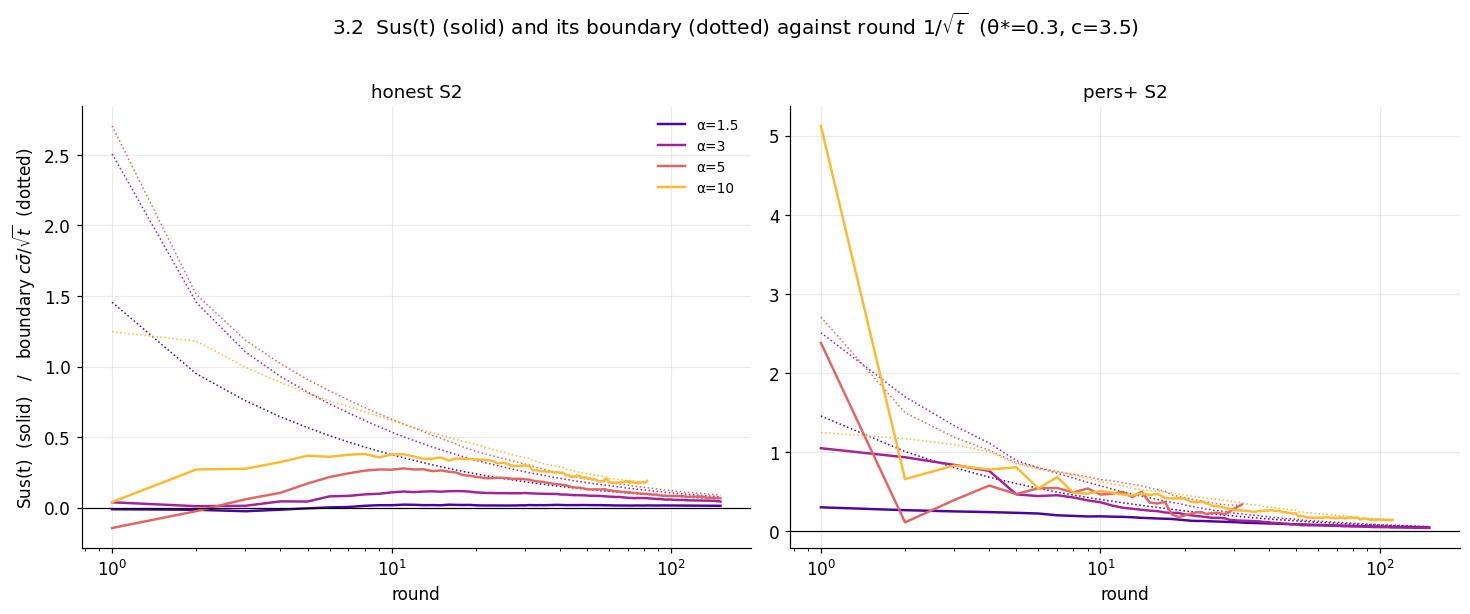

In [21]:
# 3.2 the running statistic against its own boundary.  A crossing that comes
# from a *drift* cannot be fixed by raising c -- only delayed.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
for ax, psi in zip(axes, ["inf", "high"]):
    for a in [1.5, 3.0, 5.0, 10.0]:
        q = sel(RD, study="B", psi_star=psi, theta_star=FOCUS["theta"], alpha=a,
                c=FOCUS["c"], switch_type=FOCUS["switch_type"]).sort_values("round")
        ax.plot(q["round"], q.sus1_Sus, color=ACOL[a], lw=1.6, label=f"α={a:g}")
        ax.plot(q["round"], q.threshold, color=ACOL[a], lw=1.0, ls=":")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{PSI_LABEL[psi]} S2"); ax.set_xlabel("round"); ax.set_xscale("log")
axes[0].set_ylabel("Sus(t)  (solid)   /   boundary $c\\bar\\sigma/\\sqrt{t}$  (dotted)")
axes[0].legend(fontsize=9)
fig.suptitle(f"3.2  Sus(t) (solid) and its boundary (dotted) against round "
             f"$1/\\sqrt{{t}}$  (θ*={FOCUS['theta']:g}, c={FOCUS['c']:g})", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F10_sus_vs_boundary.png"))
plt.show()

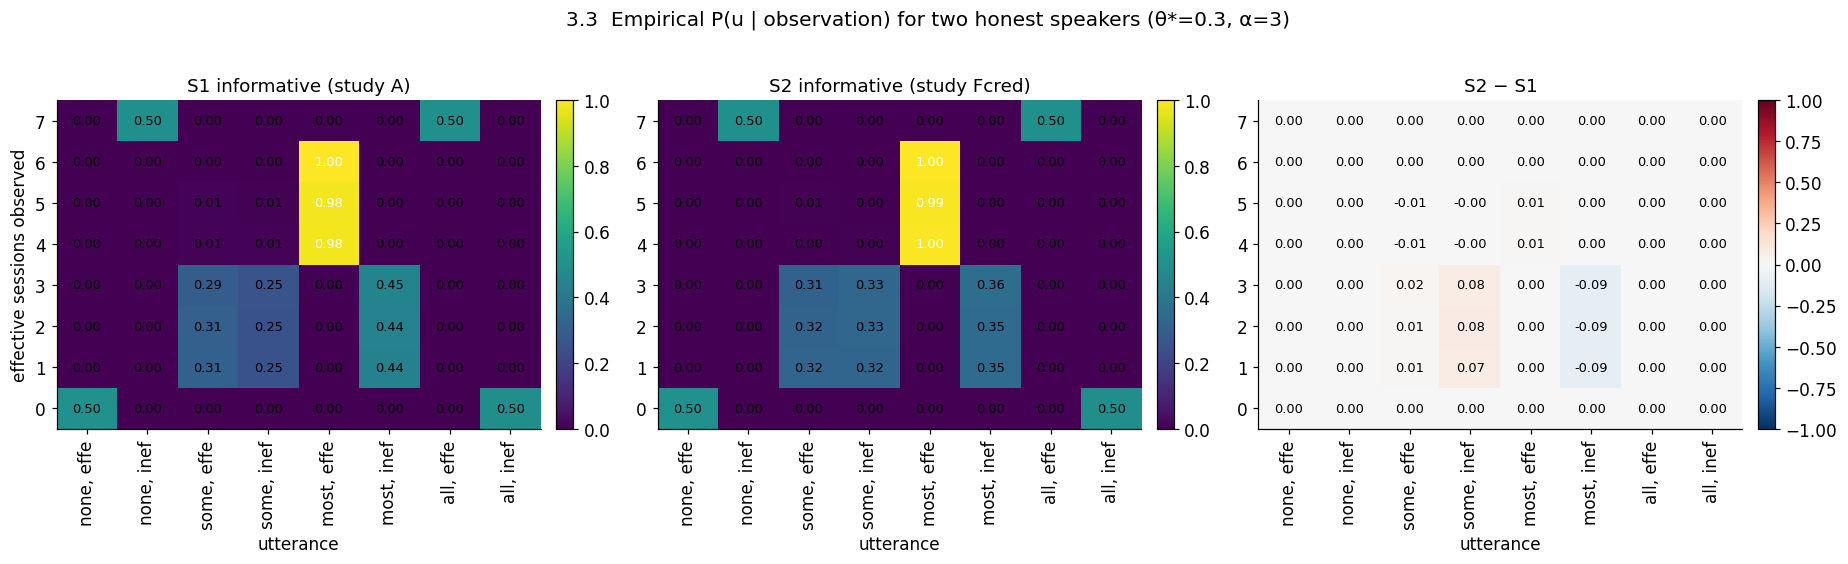

In [22]:
# 3.3 where the mismatch lives: the two speakers' utterance policies side by side
UTT = {int(k): tuple(v) for k, v in META["studies"]["A"]["utterance_index"].items()}
UTT_LABEL = [f"{UTT[i][0]}, {UTT[i][1][:4]}" for i in range(len(UTT))]

def policy_matrix(study, theta, psi, alpha, pre_switch_only=False):
    u = sel(UT, study=study, theta_star=theta, psi_star=psi, alpha=alpha)
    if pre_switch_only:
        u = u[u.switched == 0]
    m = u.groupby(["obs_count", "utt"])["n"].sum().unstack("utt").reindex(
        index=range(8), columns=range(8)).fillna(0.0)
    return m.div(m.sum(axis=1).replace(0, np.nan), axis=0)

P_S1 = policy_matrix("A", FOCUS["theta"], "inf", FOCUS["alpha"])
P_S2 = policy_matrix("Fcred", FOCUS["theta"], "inf", FOCUS["alpha"])
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
heat(axes[0], P_S1.values, UTT_LABEL, range(8), "utterance", "effective sessions observed",
     f"S1 informative (study A)", vmin=0, vmax=1)
heat(axes[1], P_S2.values, UTT_LABEL, range(8), "utterance", "",
     f"S2 informative (study Fcred)", vmin=0, vmax=1)
heat(axes[2], (P_S2 - P_S1).values, UTT_LABEL, range(8), "utterance", "",
     "S2 − S1", cmap=CMAP_DIV, vmin=-1, vmax=1)
for ax in axes:
    ax.tick_params(axis="x", rotation=90)
fig.suptitle(f"3.3  Empirical P(u | observation) for two honest speakers "
             f"(θ*={FOCUS['theta']:g}, α={FOCUS['alpha']:g})", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F11_policy_gap.png"))
plt.show()

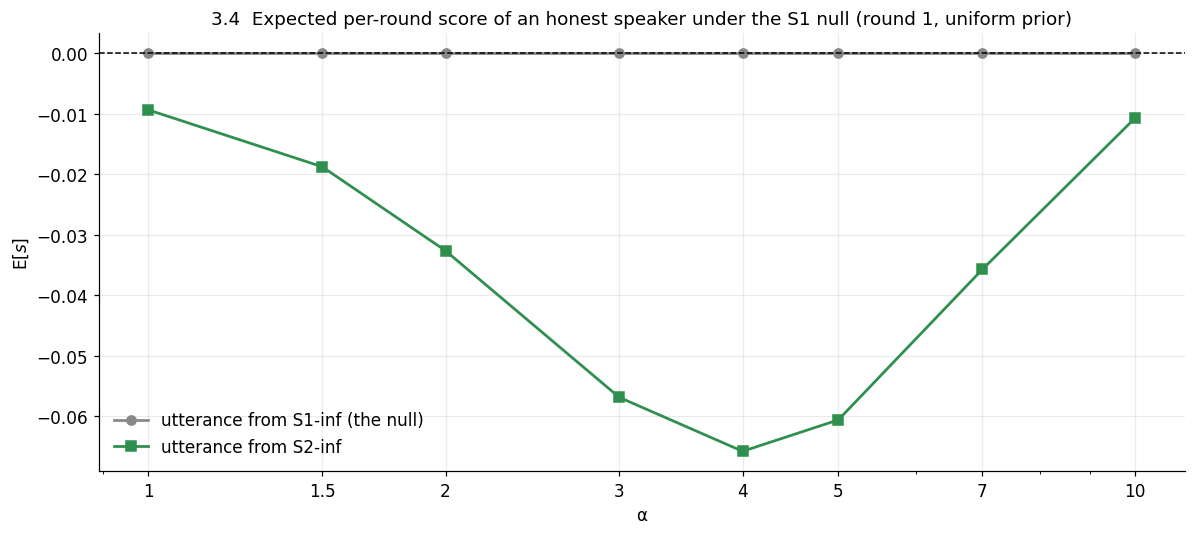

,alpha,E_score_S1,E_score_S2
0,1.0,-0.0,-0.0093
1,1.5,0.0,-0.0187
2,2.0,-0.0,-0.0326
3,3.0,-0.0,-0.0568
4,4.0,-0.0,-0.0658
5,5.0,0.0,-0.0606
6,7.0,-0.0,-0.0357
7,10.0,-0.0,-0.0106


In [23]:
# 3.4 model-level confirmation, independent of the simulations: build the two
# speakers directly and score S2's policy under S1's null.
from rsa.setup import make_thetas, make_world, make_semantics
from rsa.speaker0 import Speaker0
from rsa.listener0 import Listener0
from rsa.speaker1 import Speaker1
from rsa.listener1 import Listener1
from rsa.speaker2 import Speaker2
from rsa.detection import ScoreContext

def expected_score(alpha, theta_prior=None):
    '''E[s(u)] when the utterance comes from S1-inf vs from S2-inf, under a
    fresh credulous listener's uniform prior.'''
    TH = make_thetas(0.1)
    world, sem = make_world(0.5, n=1, m=7), make_semantics(n=1)
    s0 = Speaker0(TH, semantics=sem, world=world)
    l0 = Listener0(TH, s0, semantics=sem, world=world)
    s1 = Speaker1(TH, l0, semantics=sem, world=world, alpha=alpha, psi="inf")
    l1 = Listener1(TH, ["inf"], s1, world, sem, "inf", alpha)
    s2 = Speaker2(TH, l1, sem, world, alpha=alpha, psi="inf")
    ctx = ScoreContext(TH, s1, world, sem, l1.theta_array(), sem.utterance_space()[0])
    W = ctx.S1_table * ctx.L1_O[:, None]
    cs = W.sum(axis=0, keepdims=True)
    W = np.divide(W, cs, out=np.zeros_like(W), where=cs > 0)
    s_u = (W * ctx.B_matrix).sum(axis=0)                    # score of each utterance
    qO = ctx.L1_O
    e1 = float(qO @ (np.asarray(s1.obs_utt_table_for_psi("inf")) @ s_u))
    e2 = float(qO @ (np.asarray(s2.obs_utt_table_for_psi("inf")) @ s_u))
    return e1, e2, s_u, np.asarray(s1.obs_utt_table_for_psi("inf")), np.asarray(s2.obs_utt_table_for_psi("inf"))

rows = []
for a in ALPHAS:
    e1, e2, *_ = expected_score(a)
    rows.append(dict(alpha=a, E_score_S1=e1, E_score_S2=e2))
ES = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ES.alpha, ES.E_score_S1, "o-", color=COL["A"], lw=1.8, label="utterance from S1-inf (the null)")
ax.plot(ES.alpha, ES.E_score_S2, "s-", color=COL["B"], lw=1.8, label="utterance from S2-inf")
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_xscale("log"); ax.set_xticks(ALPHAS, [f"{a:g}" for a in ALPHAS])
finish(ax, "3.4  Expected per-round score of an honest speaker under the S1 null (round 1, uniform prior)",
       "α", "E[$s$]", save_as="F12_expected_score")
plt.show()
display(ES.round(4))

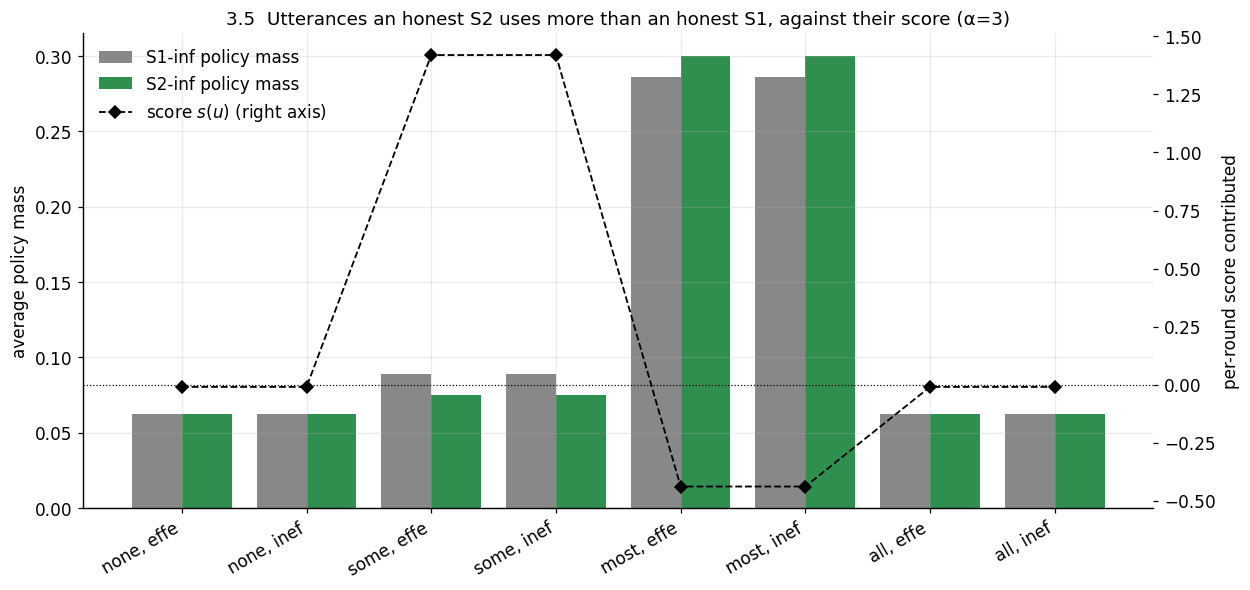

In [24]:
# 3.5 which utterances carry it, at the focus alpha
e1, e2, s_u, T1, T2 = expected_score(FOCUS["alpha"])
mass1, mass2 = T1.mean(axis=0), T2.mean(axis=0)
fig, ax = plt.subplots(figsize=(11.5, 5.5))
x = np.arange(len(s_u))
ax.bar(x - 0.2, mass1, 0.4, color=COL["A"], label="S1-inf policy mass")
ax.bar(x + 0.2, mass2, 0.4, color=COL["B"], label="S2-inf policy mass")
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(x, s_u, "kD--", ms=6, lw=1.2, label="score $s(u)$ (right axis)")
ax2.axhline(0, color="k", lw=0.8, ls=":")
ax2.set_ylabel("per-round score contributed")
ax.set_xticks(x, UTT_LABEL, rotation=30, ha="right")
h1, l1_ = ax.get_legend_handles_labels(); h2, l2_ = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1_ + l2_, loc="upper left")
finish(ax, f"3.5  Utterances an honest S2 uses more than an honest S1, against their score "
           f"(α={FOCUS['alpha']:g})", "", "average policy mass", legend=False,
       save_as="F13_utterance_scores")
plt.show()

## 4. What the switch does to beliefs

Signed bias first (it shows the *direction* a persuader pushes, which
|bias| destroys), then magnitude. Because every listener heard the same
stream in a given simulation, the switching listener is compared to its
references **pairwise**, which is far tighter than comparing group means.

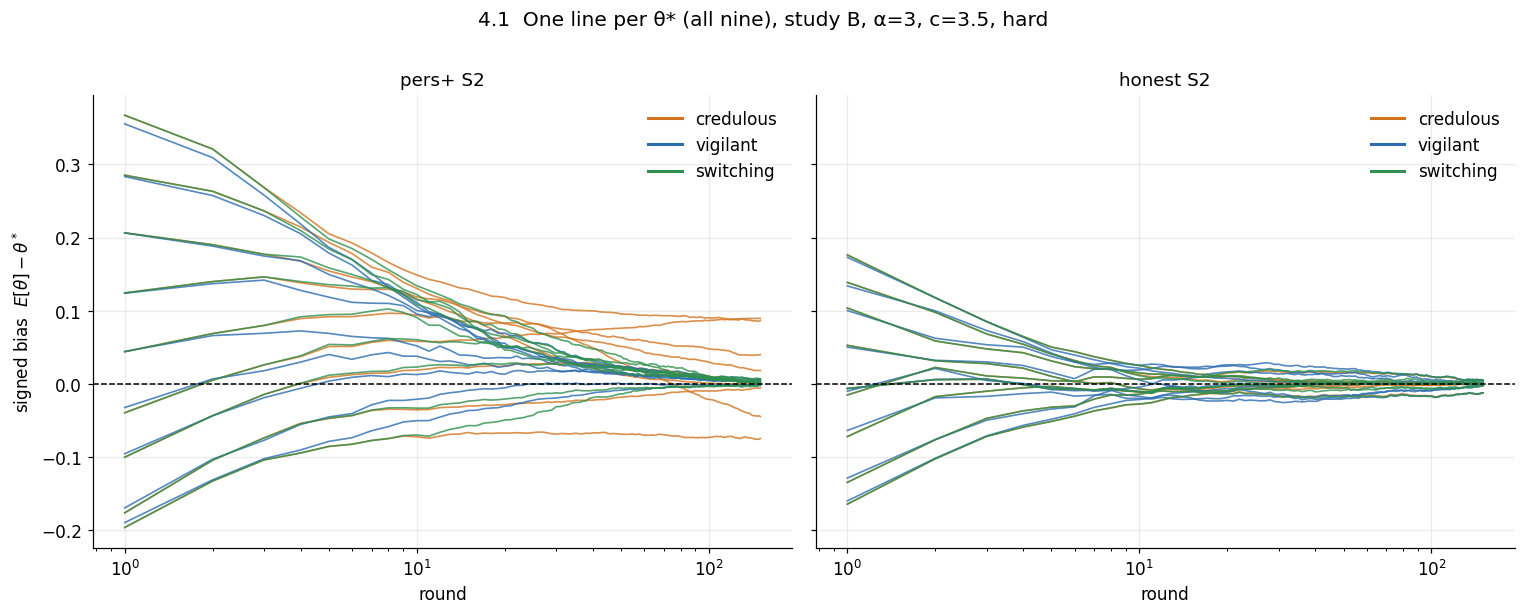

In [25]:
# 4.1 belief trajectories at one configuration, for every theta* on one axis
def bias_traj(ax, study, psi, alpha, c, st, listeners=("cred", "vig", "switch"), signed=True):
    key = "bias_" if signed else "abias_"
    for L in listeners:
        for th in THETAS:
            q = sel(RD, study=study, psi_star=psi, theta_star=th, alpha=alpha,
                    c=c, switch_type=st).sort_values("round")
            ax.plot(q["round"], q[key + L], color=COL[L], lw=1.1, alpha=0.8)
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.legend(handles=[Line2D([], [], color=COL[L], lw=2, label=LISTENER_LABEL[L]) for L in listeners])
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, psi in zip(axes, ["high", "inf"]):
    bias_traj(ax, "B", psi, FOCUS["alpha"], FOCUS["c"], FOCUS["switch_type"])
    ax.set_title(f"{PSI_LABEL[psi]} S2"); ax.set_xlabel("round"); ax.set_xscale("log")
axes[0].set_ylabel("signed bias  $E[\\theta] - \\theta^*$")
fig.suptitle(f"4.1  One line per θ* (all nine), study B, α={FOCUS['alpha']:g}, "
             f"c={FOCUS['c']:g}, {FOCUS['switch_type']}", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F14_bias_traj.png"))
plt.show()

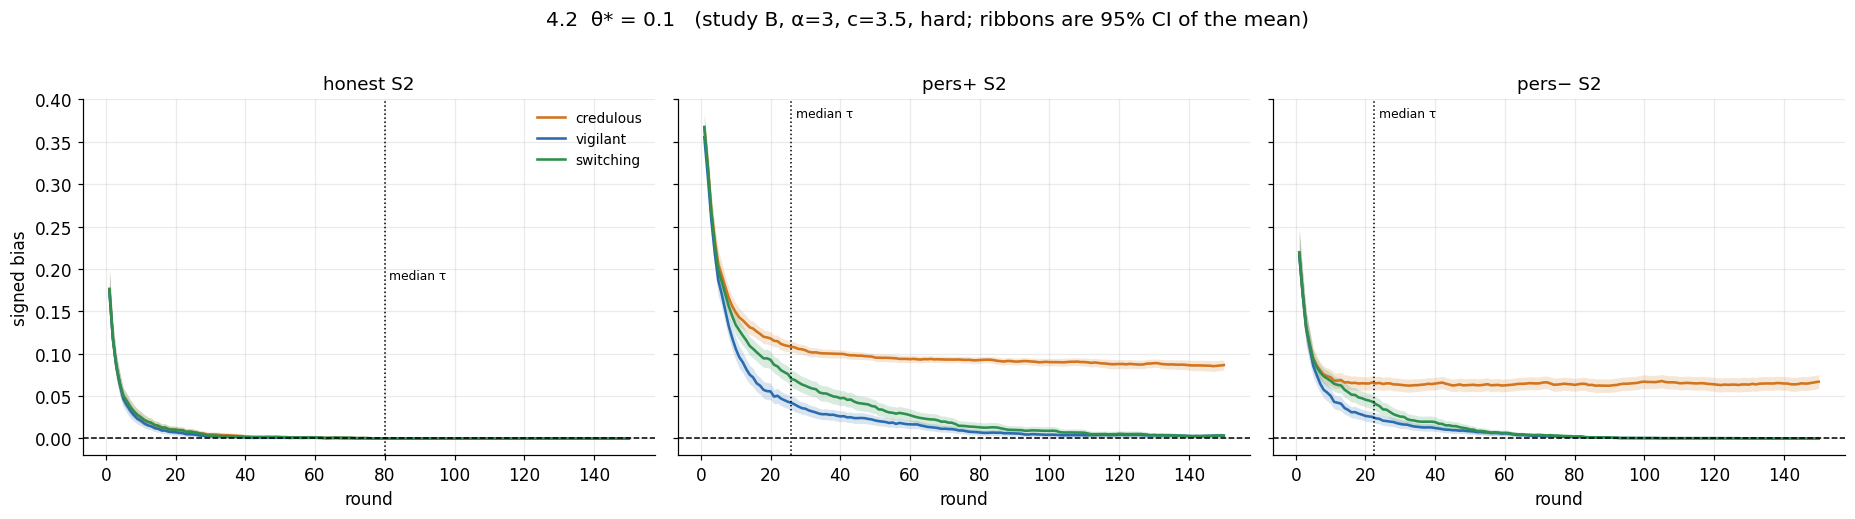

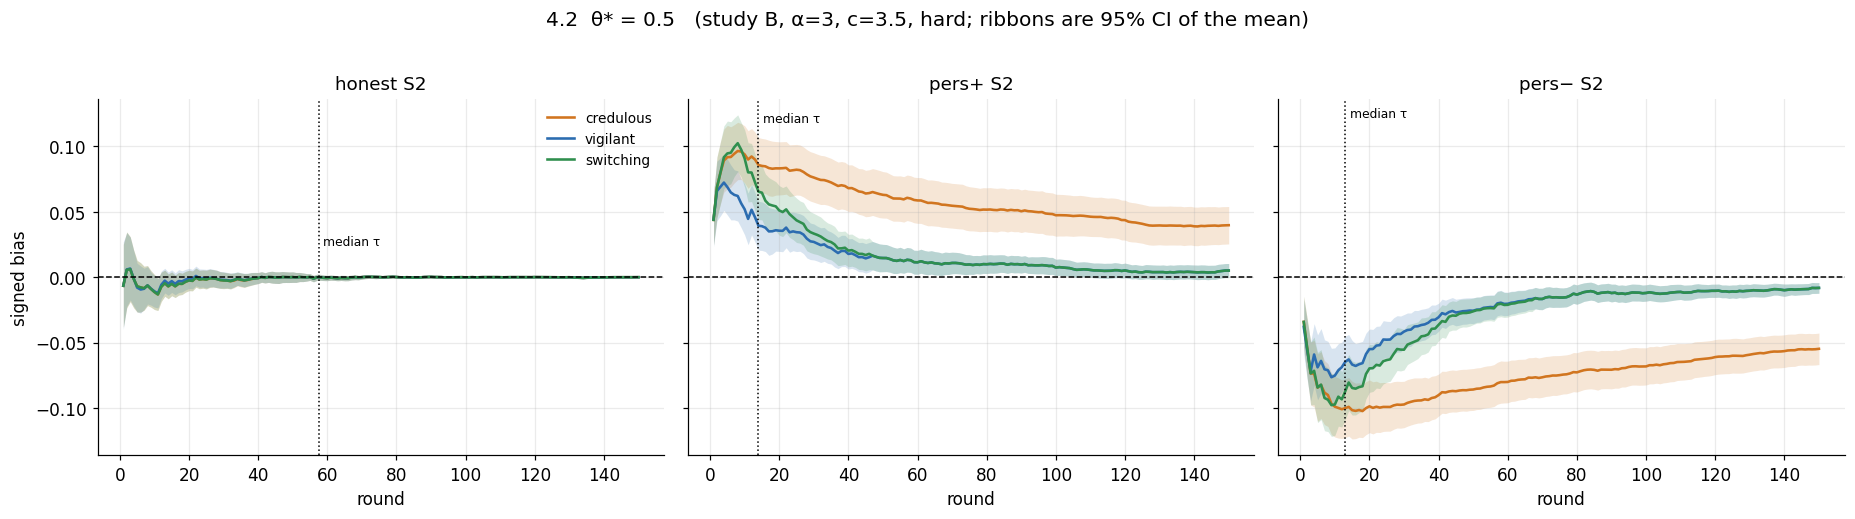

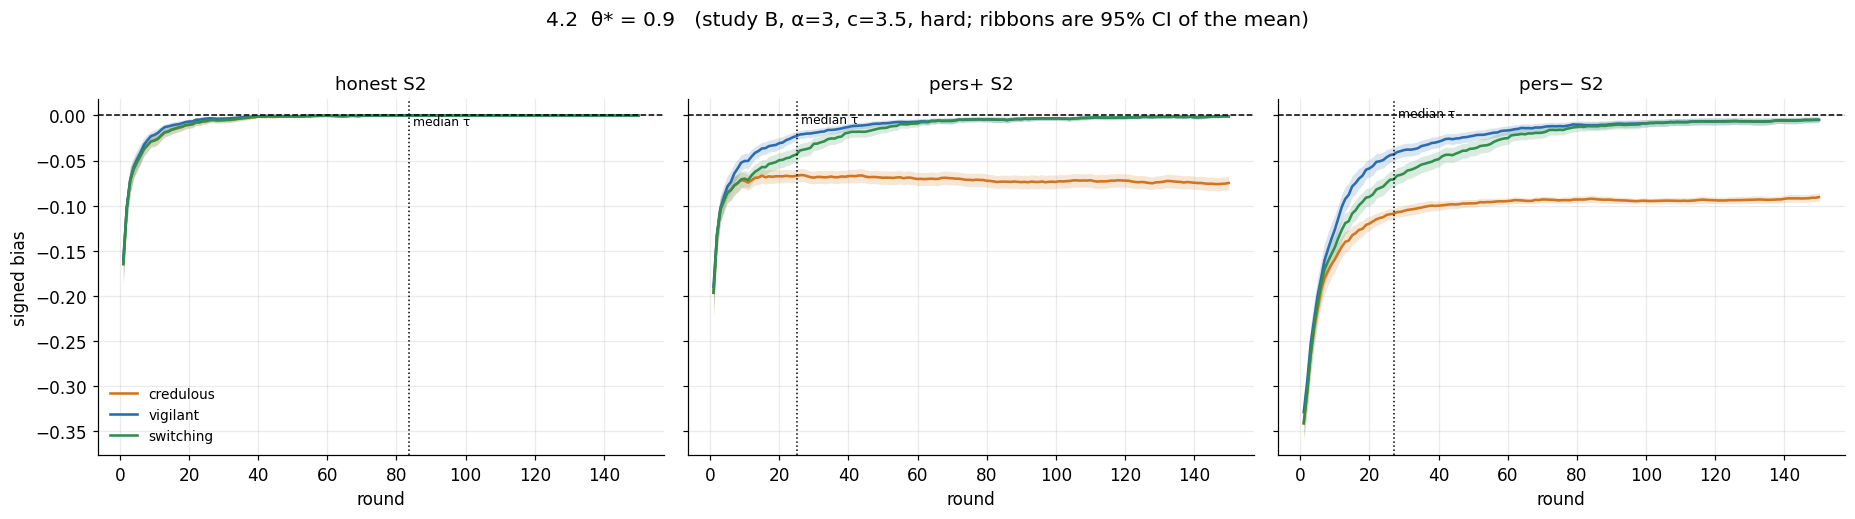

In [26]:
# 4.2 the same per theta*, full size, so the direction of the push is visible.
# Change THETAS_TO_SHOW to sweep the rest.
THETAS_TO_SHOW = [0.1, 0.5, 0.9]
for th in THETAS_TO_SHOW:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharey=True)
    for ax, psi in zip(axes, PSIS):
        for L in ("cred", "vig", "switch"):
            q = sel(RD, study="B", psi_star=psi, theta_star=th, alpha=FOCUS["alpha"],
                    c=FOCUS["c"], switch_type=FOCUS["switch_type"]).sort_values("round")
            band(ax, q["round"], q["bias_" + L], q.get(f"bias_{L}_sd", q.bias_switch_sd), q.n,
                 COL[L], label=LISTENER_LABEL[L], lw=1.7)
        sw = sel(RD, study="B", psi_star=psi, theta_star=th, alpha=FOCUS["alpha"],
                 c=FOCUS["c"], switch_type=FOCUS["switch_type"]).sort_values("round")
        med = sel(TAU, study="B", psi_star=psi, theta_star=th, alpha=FOCUS["alpha"],
                  c=FOCUS["c"], switch_type=FOCUS["switch_type"])
        med = med[med.tau > 0].tau.median()
        if np.isfinite(med):
            ax.axvline(med, color="k", lw=1, ls=":")
            ax.annotate("median τ", (med, ax.get_ylim()[1]), fontsize=8,
                        xytext=(3, -12), textcoords="offset points")
        ax.axhline(0, color="k", lw=1, ls="--")
        ax.set_title(f"{PSI_LABEL[psi]} S2"); ax.set_xlabel("round")
    axes[0].set_ylabel("signed bias"); axes[0].legend(fontsize=9)
    fig.suptitle(f"4.2  θ* = {th:g}   (study B, α={FOCUS['alpha']:g}, c={FOCUS['c']:g}, "
                 f"{FOCUS['switch_type']}; ribbons are 95% CI of the mean)", y=1.02)
    fig.tight_layout()
    if SAVE: fig.savefig(os.path.join(FIG_DIR, f"F15_bias_theta{th:g}.png"))
    plt.show()

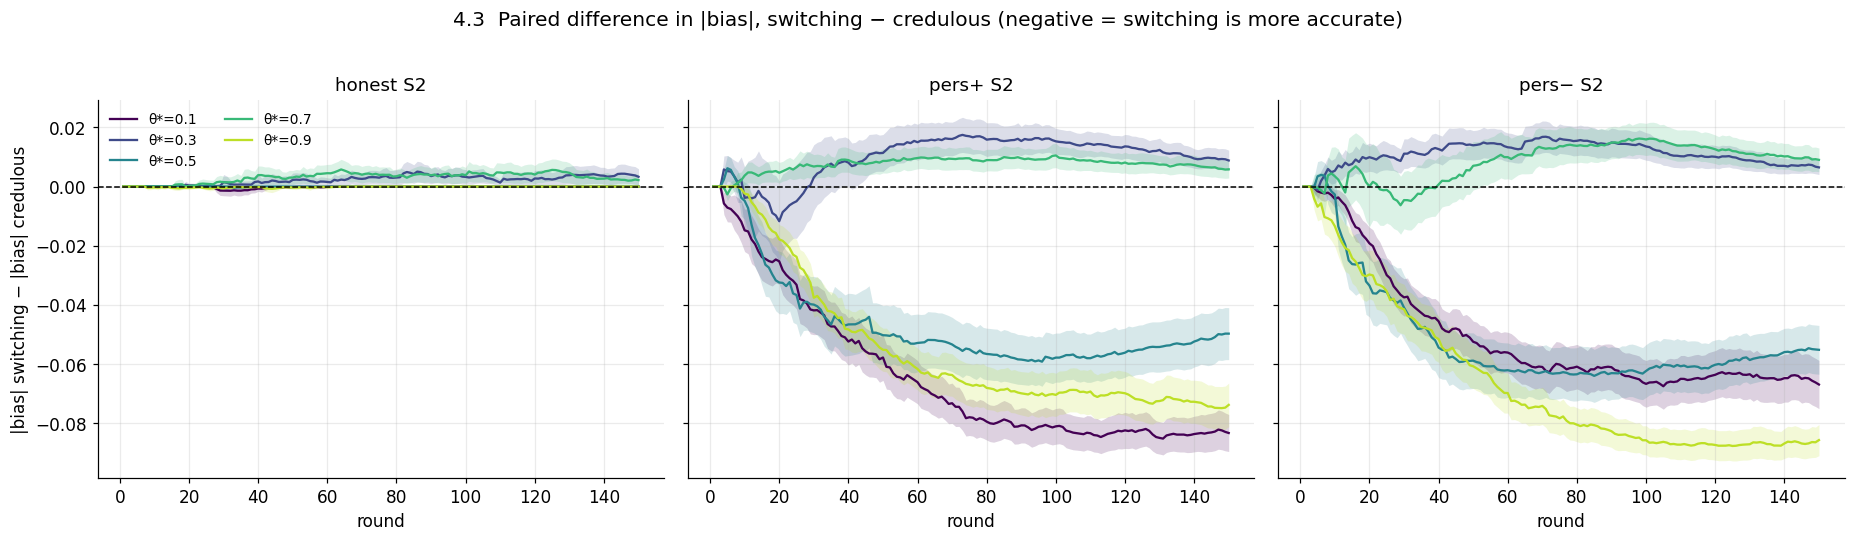

In [27]:
# 4.3 paired differences: switching listener minus each reference, same simulation
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for th in [0.1, 0.3, 0.5, 0.7, 0.9]:
        q = sel(RD, study="B", psi_star=psi, theta_star=th, alpha=FOCUS["alpha"],
                c=FOCUS["c"], switch_type=FOCUS["switch_type"]).sort_values("round")
        band(ax, q["round"], q.ad_switch_cred, q.ad_switch_cred_sd, q.n, TCOL[th],
             label=f"θ*={th:g}", lw=1.5)
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_title(f"{PSI_LABEL[psi]} S2"); ax.set_xlabel("round")
axes[0].set_ylabel("|bias| switching − |bias| credulous")
axes[0].legend(fontsize=9, ncol=2)
fig.suptitle("4.3  Paired difference in |bias|, switching − credulous "
             "(negative = switching is more accurate)", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F16_paired_vs_cred.png"))
plt.show()

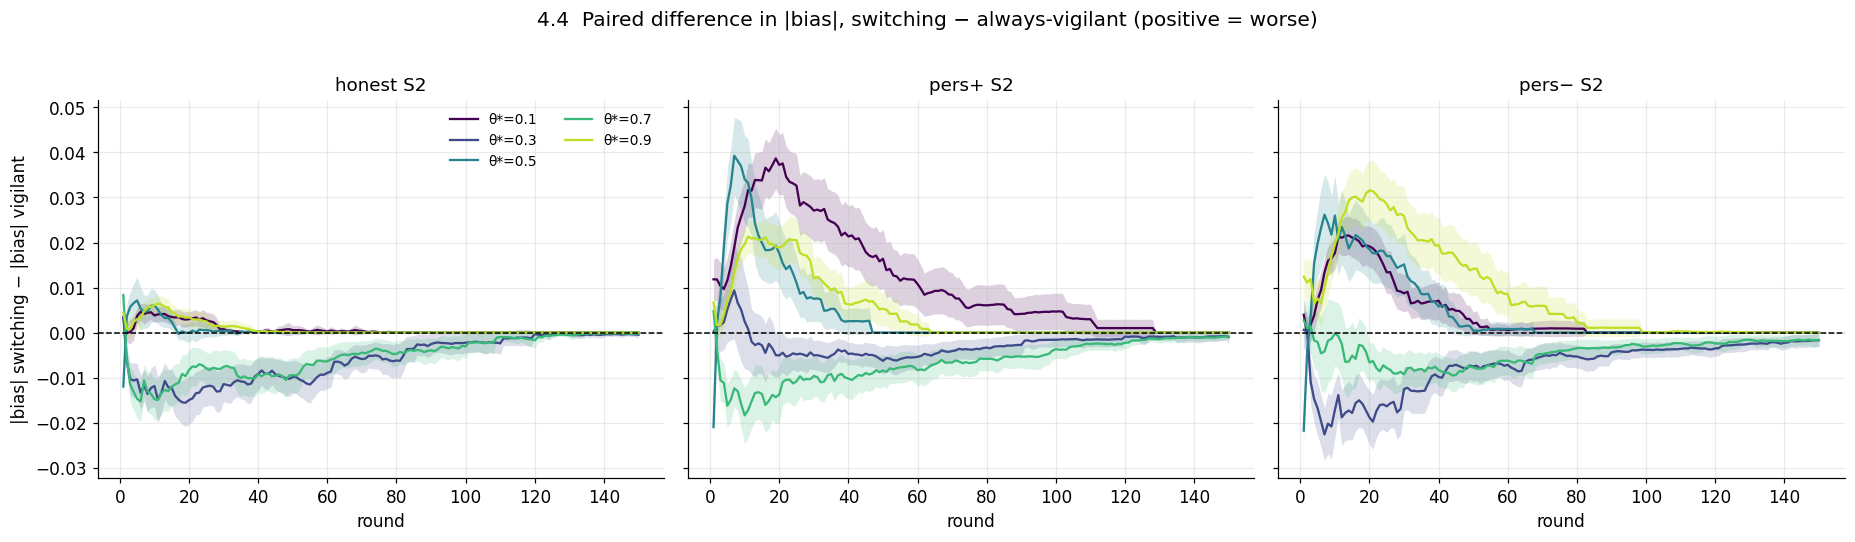

In [28]:
# 4.4 ... and the cost side: switching vs having been vigilant all along
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for th in [0.1, 0.3, 0.5, 0.7, 0.9]:
        q = sel(RD, study="B", psi_star=psi, theta_star=th, alpha=FOCUS["alpha"],
                c=FOCUS["c"], switch_type=FOCUS["switch_type"]).sort_values("round")
        band(ax, q["round"], q.ad_switch_vig, q.ad_switch_vig_sd, q.n, TCOL[th],
             label=f"θ*={th:g}", lw=1.5)
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_title(f"{PSI_LABEL[psi]} S2"); ax.set_xlabel("round")
axes[0].set_ylabel("|bias| switching − |bias| vigilant")
axes[0].legend(fontsize=9, ncol=2)
fig.suptitle("4.4  Paired difference in |bias|, switching − always-vigilant (positive = worse)", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F17_paired_vs_vig.png"))
plt.show()

### 4.5 Accuracy over the whole conversation, not at the end of it

With 150 rounds every listener converges on 	heta^* under any speaker, so
*terminal* bias is degenerate (see the table below: |bias| at round 150 is
~1e-4). The cost of a listening strategy is what it believed **throughout**,
so the rest of this section uses the time-averaged |bias|.

In [29]:
def avg_abias(study, st=None, c=None, upto=None):
    '''Time-averaged |bias| per (psi*, alpha, theta*) for one (c, switch_type).'''
    st = st or FOCUS["switch_type"]
    c = c if c is not None else FOCUS["c"]
    q = sel(RD, study=study, switch_type=st, c=c)
    if upto is not None:
        q = q[q["round"] <= upto]
    g = (q.groupby(["psi_star", "alpha", "theta_star"])[["abias_cred", "abias_vig", "abias_switch"]]
          .mean().reset_index())
    g["vig_minus_cred"] = g.abias_vig - g.abias_cred
    g["switch_minus_cred"] = g.abias_switch - g.abias_cred
    g["switch_minus_best"] = g.abias_switch - np.minimum(g.abias_cred, g.abias_vig)
    return g

demo = sel(RD, study="B", psi_star="high", theta_star=0.3, alpha=3.0,
           c=FOCUS["c"], switch_type=FOCUS["switch_type"]).sort_values("round")
print("Study B, pers+ S2, θ*=0.3, α=3 — |bias| by round:")
display(demo[demo["round"].isin([10, 25, 50, 100, 150])][
    ["round", "abias_cred", "abias_vig", "abias_switch"]].round(4).to_string(index=False))
print("time-averaged over all 150 rounds:",
      demo[["abias_cred", "abias_vig", "abias_switch"]].mean().round(4).to_dict())

Study B, pers+ S2, θ*=0.3, α=3 — |bias| by round:


' round  abias_cred  abias_vig  abias_switch\n    10      0.1274     0.1212        0.1236\n    25      0.0590     0.0589        0.0540\n    50      0.0190     0.0366        0.0303\n   100      0.0023     0.0192        0.0176\n   150      0.0003     0.0101        0.0091'

time-averaged over all 150 rounds: {'abias_cred': 0.028300000354647636, 'abias_vig': 0.040800001472234726, 'abias_switch': 0.03830000013113022}


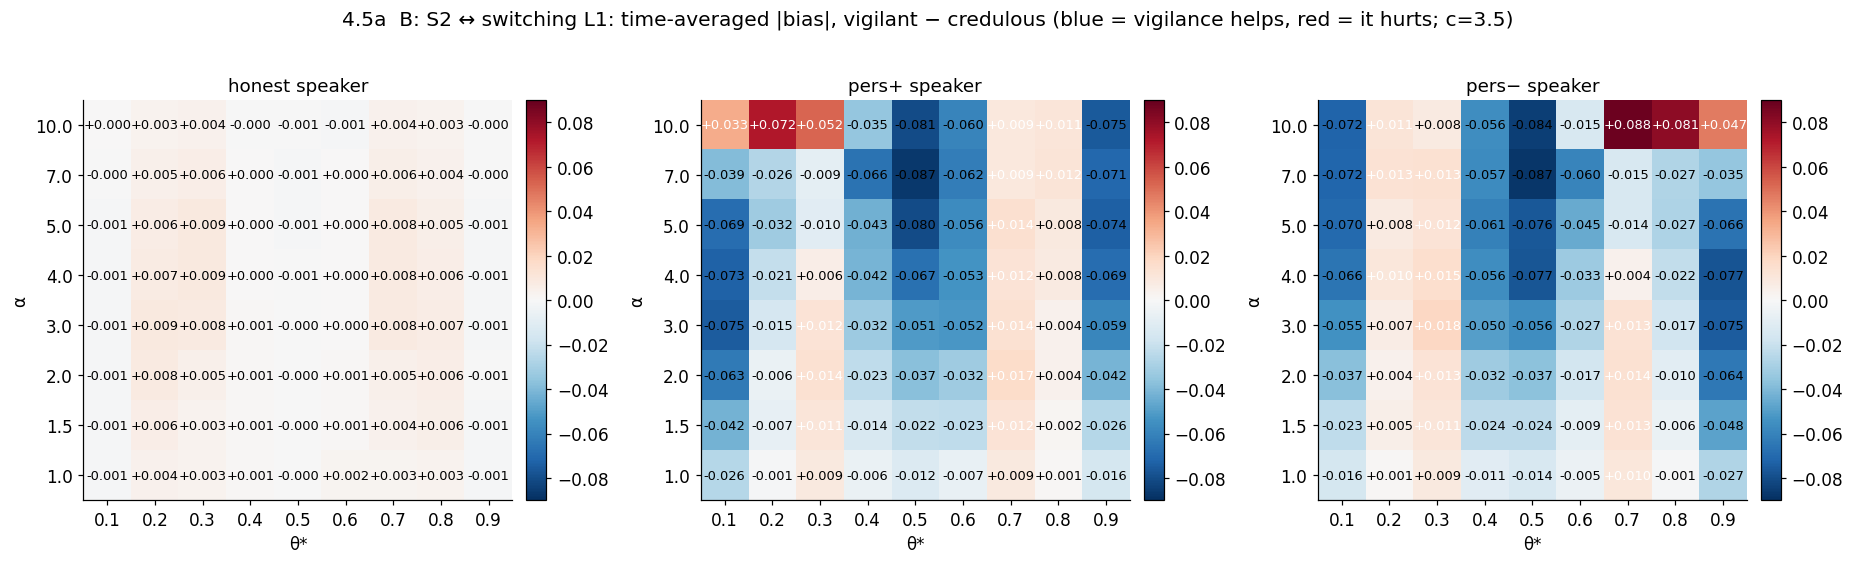

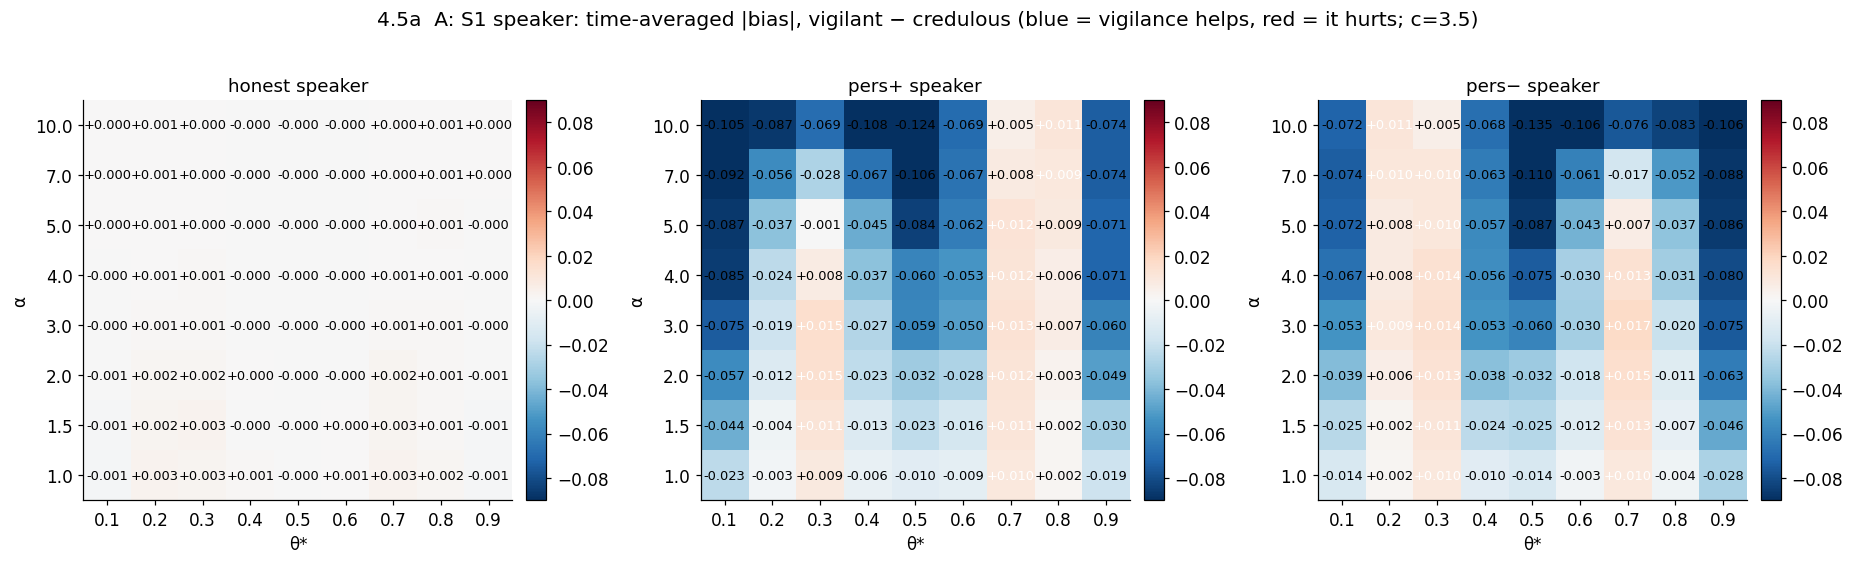

In [30]:
# 4.5a  Does vigilance pay at all?  Vigilant minus credulous, time-averaged.
for study in ["B", "A"]:
    G = avg_abias(study)
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    for ax, psi in zip(axes, PSIS):
        M = G[G.psi_star == psi].pivot(index="alpha", columns="theta_star", values="vig_minus_cred")
        heat(ax, M.values, M.columns, M.index, "θ*", "α", f"{PSI_LABEL[psi]} speaker",
             cmap=CMAP_DIV, vmin=-0.09, vmax=0.09, fmt="{:+.3f}")
    fig.suptitle(f"4.5a  {STUDY_LABEL[study]}: time-averaged |bias|, vigilant − credulous "
                 f"(blue = vigilance helps, red = it hurts; c={FOCUS['c']:g})", y=1.02)
    fig.tight_layout()
    if SAVE: fig.savefig(os.path.join(FIG_DIR, f"F18_vig_vs_cred_{study}.png"))
    plt.show()

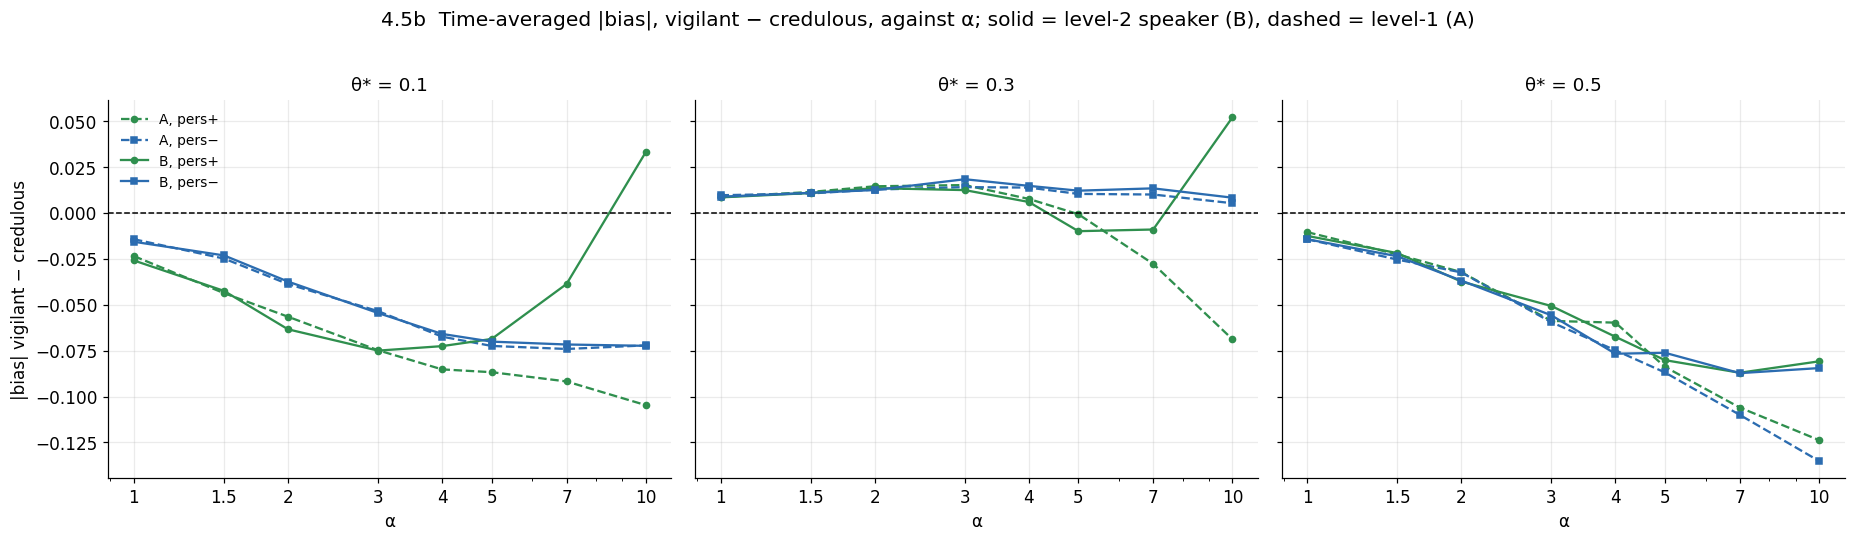

In [31]:
# 4.5b  the flip, read as curves: against a level-1 persuader vigilance keeps
# paying as alpha grows; against a level-2 one it stops, and reverses.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, th in zip(axes, [0.1, 0.3, 0.5]):
    for study, ls in [("A", "--"), ("B", "-")]:
        G = avg_abias(study)
        for psi in ["high", "low"]:
            q = G[(G.psi_star == psi) & (G.theta_star == th)].sort_values("alpha")
            ax.plot(q.alpha, q.vig_minus_cred, ls, marker="o" if psi == "high" else "s",
                    color=COL["B"] if psi == "high" else COL["vig"], ms=4, lw=1.5,
                    label=f"{study}, {PSI_LABEL[psi]}" if ax is axes[0] else None)
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_xscale("log"); ax.set_xticks(ALPHAS, [f"{a:g}" for a in ALPHAS])
    ax.set_title(f"θ* = {th:g}"); ax.set_xlabel("α")
axes[0].set_ylabel("|bias| vigilant − credulous")
axes[0].legend(fontsize=9)
fig.suptitle("4.5b  Time-averaged |bias|, vigilant − credulous, against α; "
             "solid = level-2 speaker (B), dashed = level-1 (A)", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F19_vig_flip.png"))
plt.show()

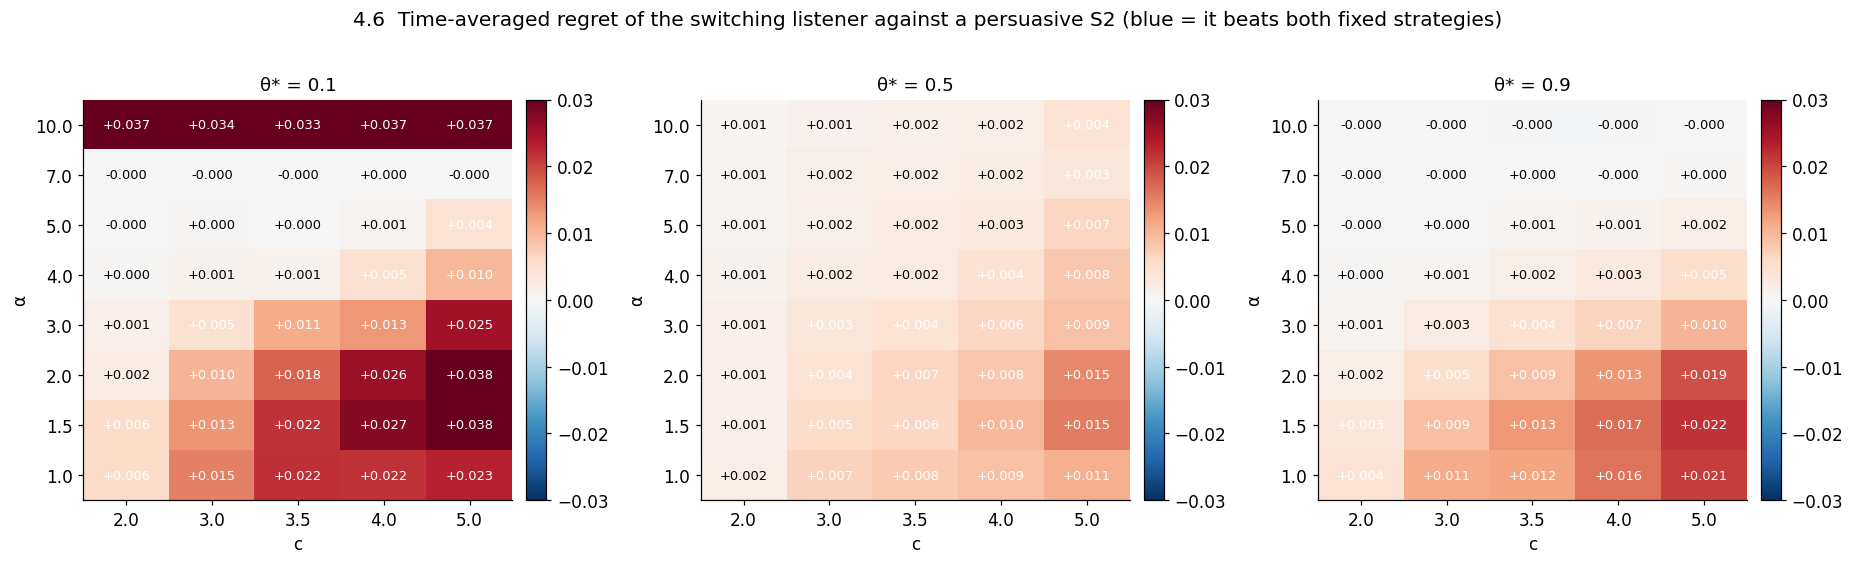

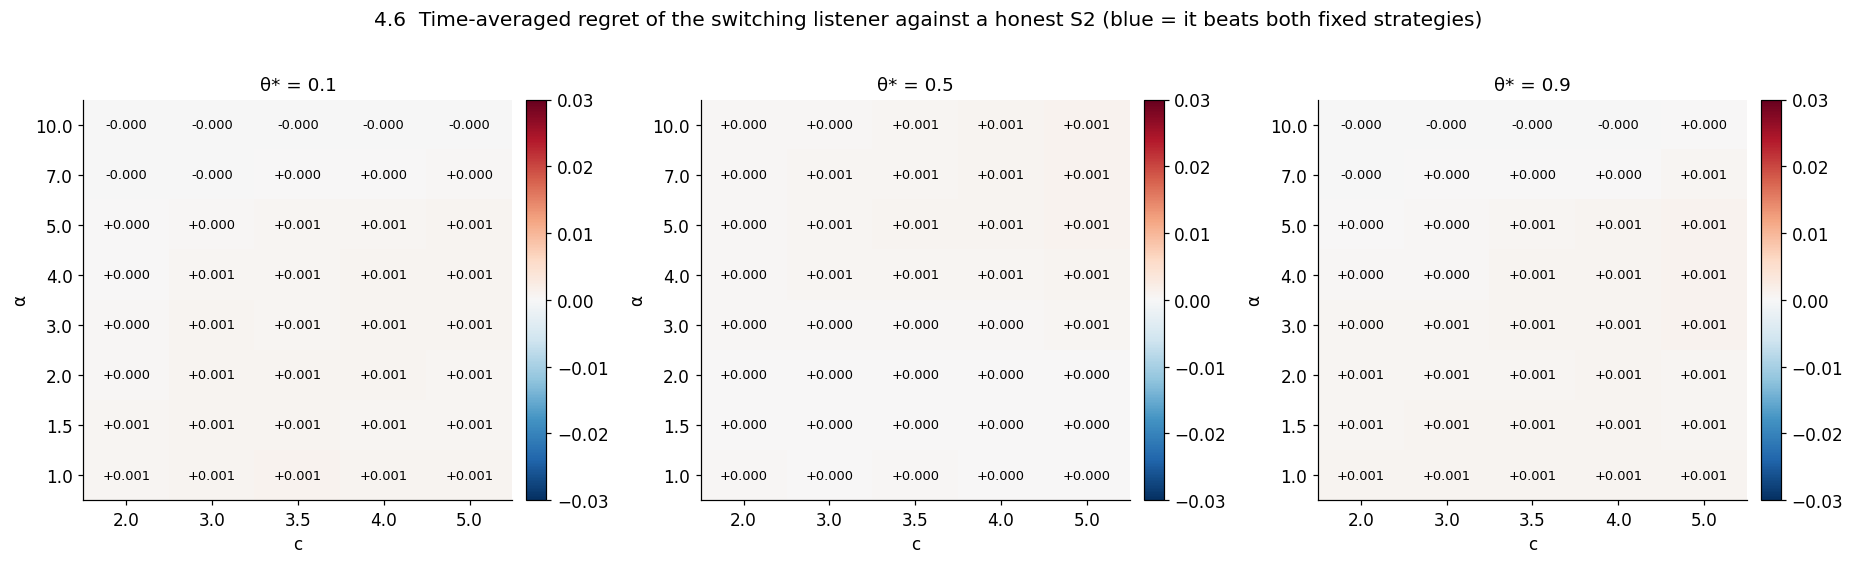

In [32]:
# 4.6 regret of the switching listener against the better fixed strategy,
# over the whole (alpha, c) design, per theta*.
def regret_grid(psi, th, st=None, upto=None):
    st = st or FOCUS["switch_type"]
    q = sel(RD, study="B", psi_star=psi, theta_star=th, switch_type=st)
    if upto is not None:
        q = q[q["round"] <= upto]
    g = (q.groupby(["alpha", "c"])[["abias_cred", "abias_vig", "abias_switch"]]
          .mean().reset_index())
    g["regret"] = g.abias_switch - np.minimum(g.abias_cred, g.abias_vig)
    return g.pivot(index="alpha", columns="c", values="regret")

for psi, tag in [("high", "persuasive"), ("inf", "honest")]:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    for ax, th in zip(axes, [0.1, 0.5, 0.9]):
        G = regret_grid(psi, th)
        heat(ax, G.values, G.columns, G.index, "c", "α", f"θ* = {th:g}",
             cmap=CMAP_DIV, vmin=-0.03, vmax=0.03, fmt="{:+.3f}")
    fig.suptitle(f"4.6  Time-averaged regret of the switching listener against a {tag} S2 "
                 "(blue = it beats both fixed strategies)", y=1.02)
    fig.tight_layout()
    if SAVE: fig.savefig(os.path.join(FIG_DIR, f"F20_regret_{psi}.png"))
    plt.show()

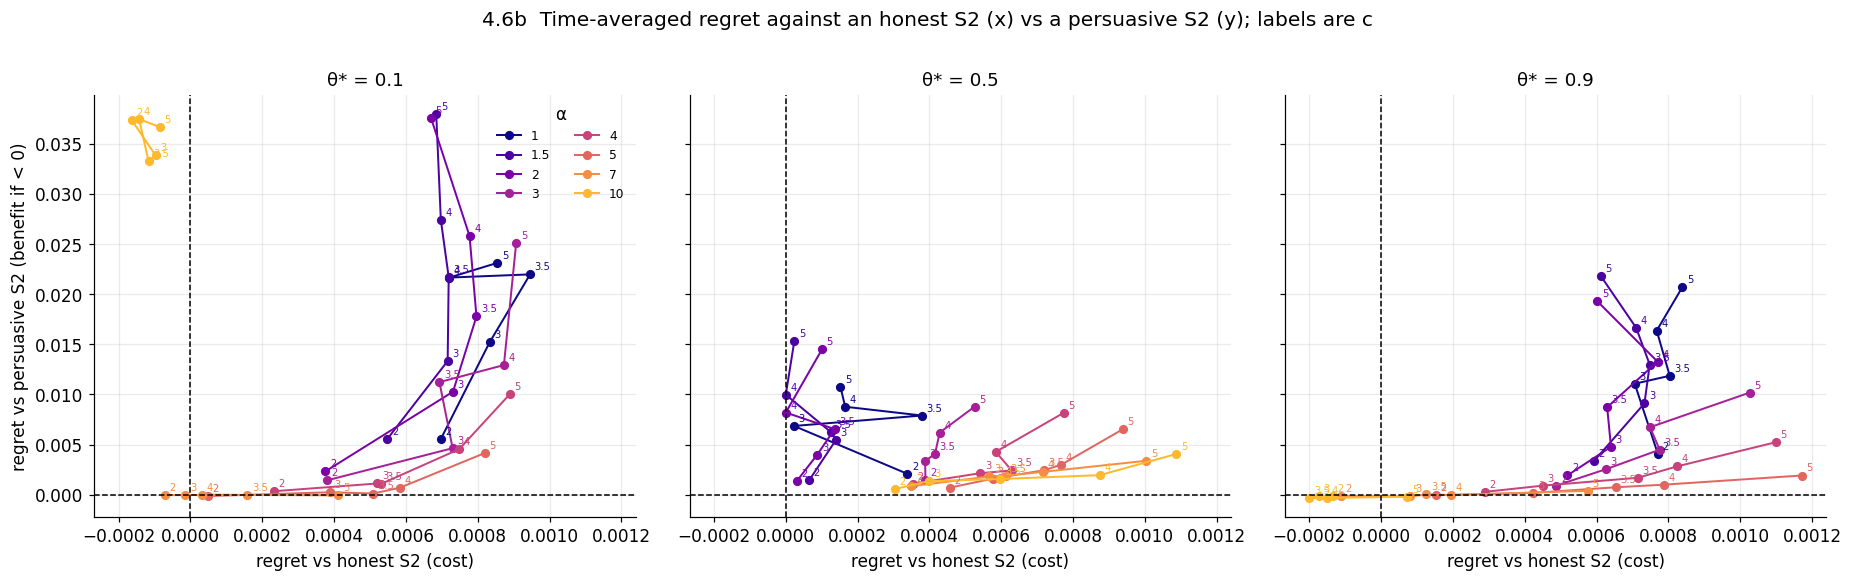

In [33]:
# 4.6b the operating-point question in one picture: cost against an honest
# speaker on x, benefit against a persuasive one on y, for every (alpha, c).
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), sharex=True, sharey=True)
for ax, th in zip(axes, [0.1, 0.5, 0.9]):
    Rh, Rp = regret_grid("inf", th), regret_grid("high", th)
    for a in ALPHAS:
        ax.plot(Rh.loc[a].values, Rp.loc[a].values, "o-", color=ACOL[a], ms=5, lw=1.3,
                label=f"{a:g}" if ax is axes[0] else None)
        for c in CS:
            ax.annotate(f"{c:g}", (Rh.loc[a, c], Rp.loc[a, c]), fontsize=6.5,
                        xytext=(3, 3), textcoords="offset points", color=ACOL[a])
    ax.axhline(0, color="k", lw=1, ls="--"); ax.axvline(0, color="k", lw=1, ls="--")
    ax.set_title(f"θ* = {th:g}"); ax.set_xlabel("regret vs honest S2 (cost)")
axes[0].set_ylabel("regret vs persuasive S2 (benefit if < 0)")
axes[0].legend(title="α", ncol=2, fontsize=8)
fig.suptitle("4.6b  Time-averaged regret against an honest S2 (x) vs a persuasive S2 (y); "
             "labels are c", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F21_cost_benefit.png"))
plt.show()

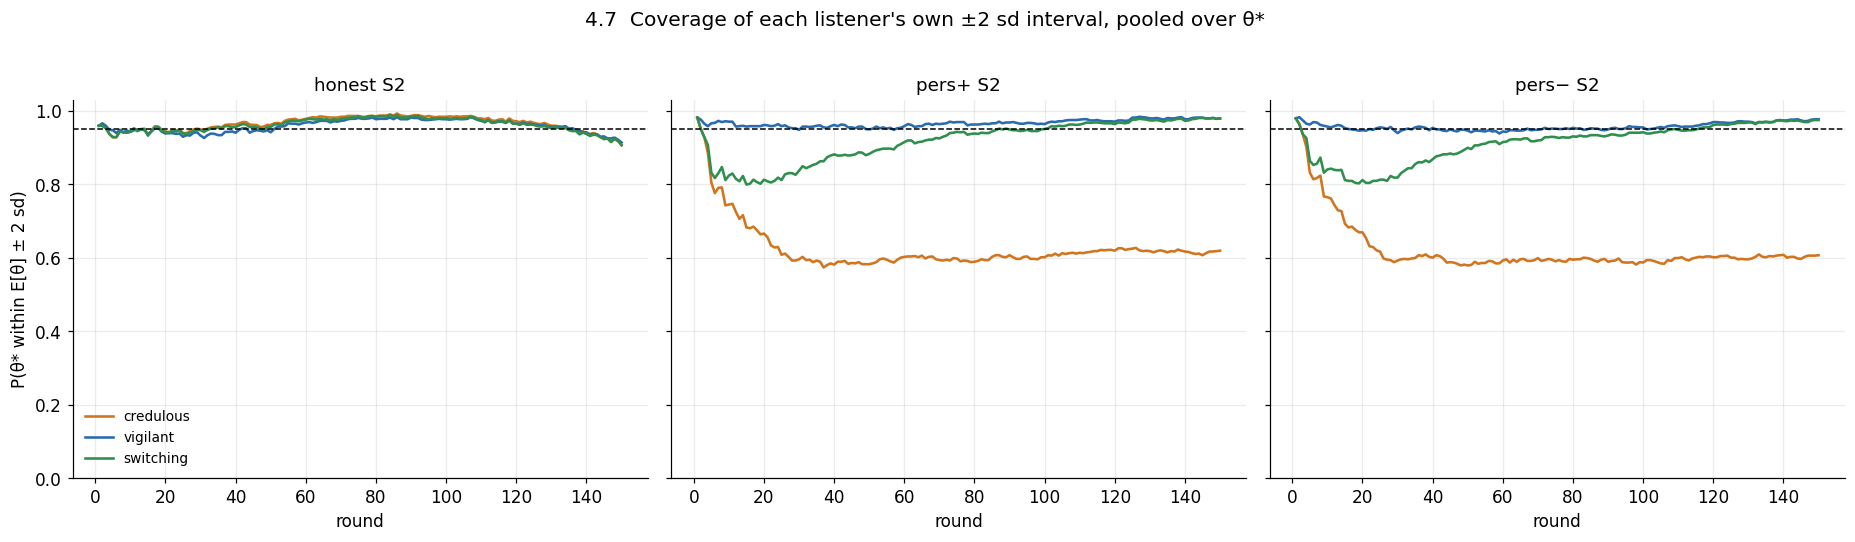

In [34]:
# 4.7 is the uncertainty honest?  Coverage of the listener's own +/-2 sd interval.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for L in ("cred", "vig", "switch"):
        q = (sel(RD, study="B", psi_star=psi, alpha=FOCUS["alpha"], c=FOCUS["c"],
                 switch_type=FOCUS["switch_type"])
             .groupby("round")[f"cov_{L}"].mean())
        ax.plot(q.index, q.values, color=COL[L], lw=1.7, label=LISTENER_LABEL[L])
    ax.axhline(0.95, color="k", lw=1, ls="--")
    ax.set_title(f"{PSI_LABEL[psi]} S2"); ax.set_xlabel("round"); ax.set_ylim(0, 1.03)
axes[0].set_ylabel("P(θ* within E[θ] ± 2 sd)")
axes[0].legend(fontsize=9)
fig.suptitle("4.7  Coverage of each listener's own ±2 sd interval, pooled over θ* "
             "", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F21_coverage.png"))
plt.show()

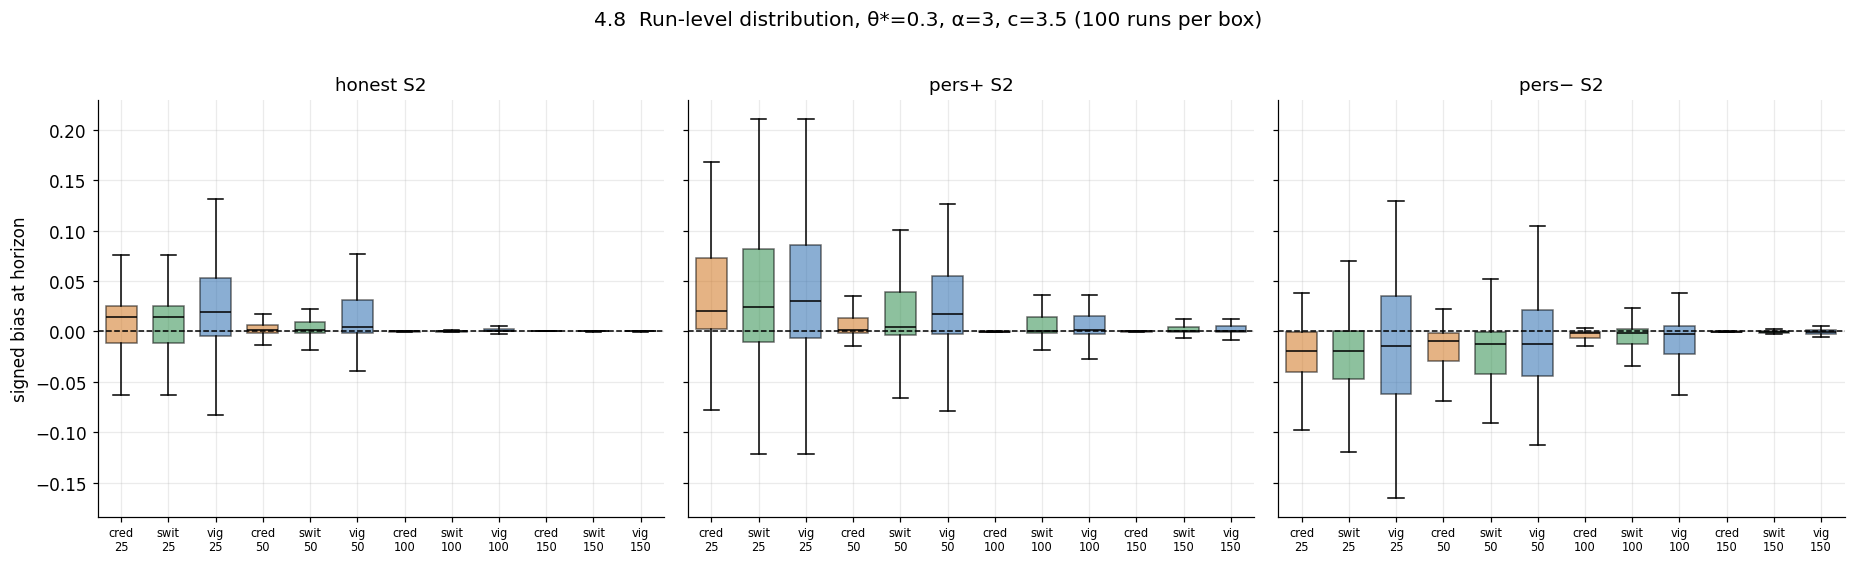

In [35]:
# 4.8 run-level spread at the horizons (means hide the tails)
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, psi in zip(axes, PSIS):
    data, labels, colors = [], [], []
    for h in ["25", "50", "100", "150"]:
        for L in ("cred", "switch", "vig"):
            r = sel(RU, study="B", psi_star=psi, alpha=FOCUS["alpha"], c=FOCUS["c"],
                    switch_type=FOCUS["switch_type"], horizon=h, theta_star=FOCUS["theta"])
            data.append(r[f"bias_{L}"].dropna().to_numpy()); labels.append(f"{L[:4]}\n{h}")
            colors.append(COL[L])
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.65)
    for patch, cl in zip(bp["boxes"], colors):
        patch.set_facecolor(cl); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_title(f"{PSI_LABEL[psi]} S2"); ax.tick_params(axis="x", labelsize=7.5)
axes[0].set_ylabel("signed bias at horizon")
fig.suptitle(f"4.8  Run-level distribution, θ*={FOCUS['theta']:g}, α={FOCUS['alpha']:g}, "
             f"c={FOCUS['c']:g} (100 runs per box)", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F22_run_spread.png"))
plt.show()

## 5. Hard vs soft

**hard** = a vigilant L1 that has been listening from round 1 takes over at τ
(equivalent to a full retrospective replay). **soft** = a fresh vigilant L1
inherits the credulous θ-marginal from just before u<sub>τ</sub>, uniform over ψ.

In the offline studies both see the same stream, so they differ only *after* τ.
In B they differ *before* τ as well, because the speaker can see through
`peek`/`peek_obs` which audience it faces.

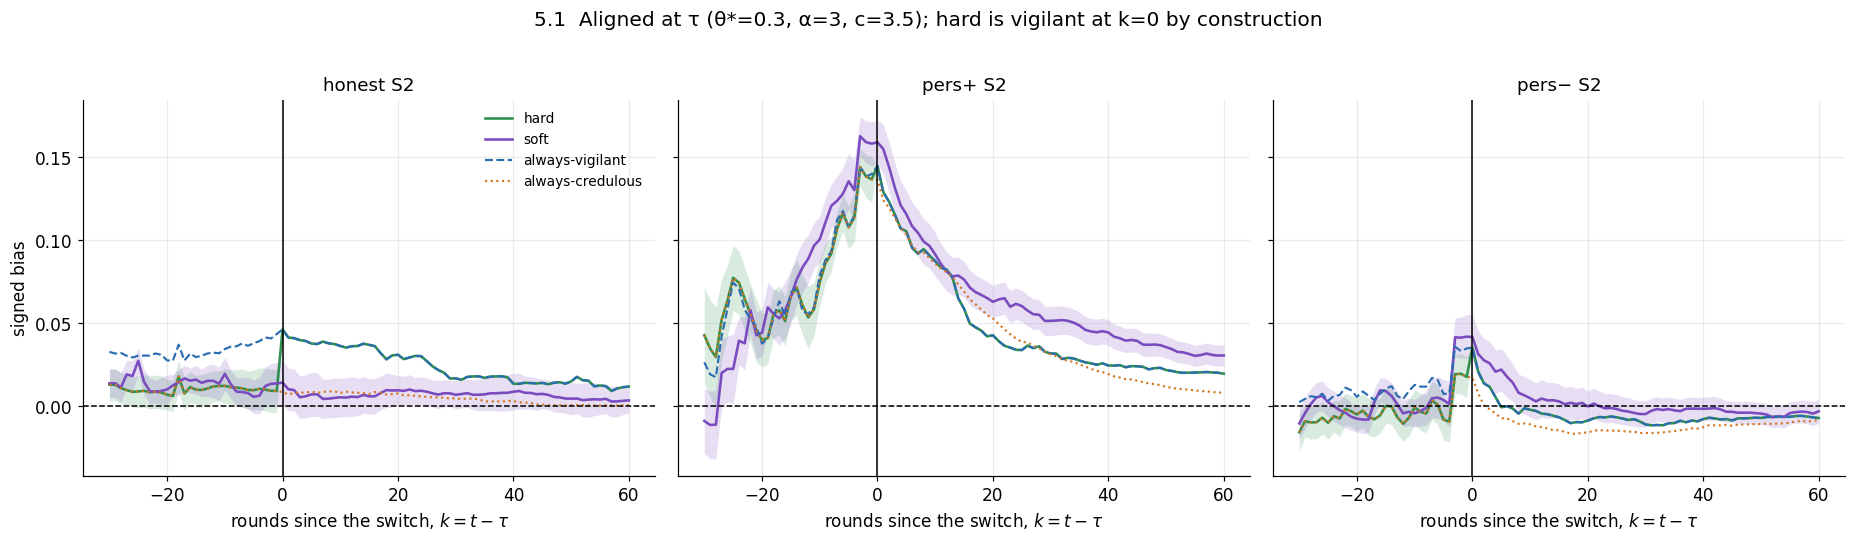

In [36]:
# 5.1 recovery after the alarm, aligned at tau
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for st in SWITCH:
        q = sel(AL, study="B", psi_star=psi, theta_star=FOCUS["theta"], alpha=FOCUS["alpha"],
                c=FOCUS["c"], switch_type=st).sort_values("k")
        band(ax, q.k, q.bias_switch, q.d_switch_vig_sd, q.n, COL[st], label=st, lw=1.7)
    q = sel(AL, study="B", psi_star=psi, theta_star=FOCUS["theta"], alpha=FOCUS["alpha"],
            c=FOCUS["c"], switch_type="hard").sort_values("k")
    ax.plot(q.k, q.bias_vig, color=COL["vig"], lw=1.4, ls="--", label="always-vigilant")
    ax.plot(q.k, q.bias_cred, color=COL["cred"], lw=1.4, ls=":", label="always-credulous")
    ax.axvline(0, color="k", lw=1); ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_title(f"{PSI_LABEL[psi]} S2"); ax.set_xlabel("rounds since the switch, $k = t - \\tau$")
axes[0].set_ylabel("signed bias"); axes[0].legend(fontsize=9)
fig.suptitle(f"5.1  Aligned at τ (θ*={FOCUS['theta']:g}, α={FOCUS['alpha']:g}, "
             f"c={FOCUS['c']:g}); hard is vigilant at k=0 by construction", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F23_aligned_recovery.png"))
plt.show()

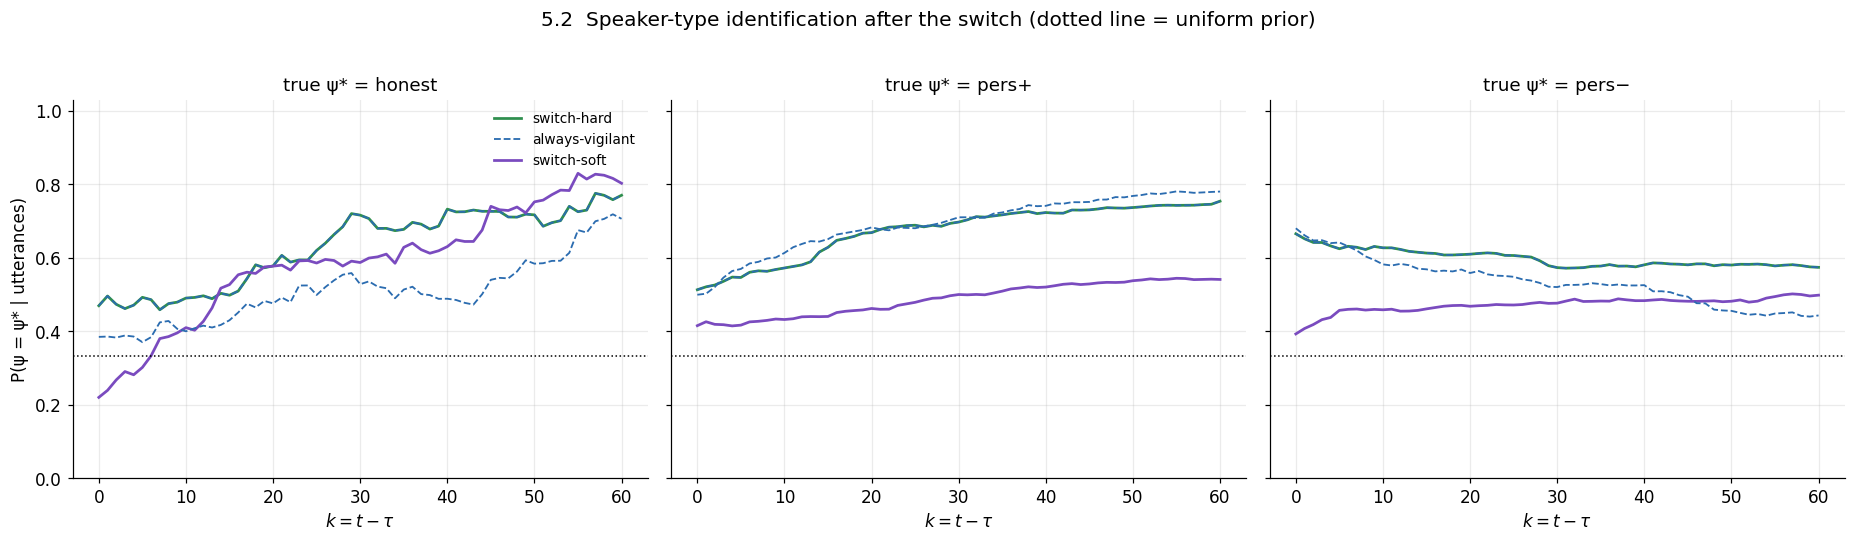

In [37]:
# 5.2 how fast does the switched listener work out who it is talking to?
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for st in SWITCH:
        q = sel(AL, study="B", psi_star=psi, theta_star=FOCUS["theta"], alpha=FOCUS["alpha"],
                c=FOCUS["c"], switch_type=st).sort_values("k")
        q = q[q.k >= 0]
        ax.plot(q.k, q[f"p_psi_switch_{psi}"], color=COL[st], lw=1.8, label=f"switch-{st}")
        ax.plot(q.k, q[f"p_psi_vig_{psi}"], color=COL["vig"], lw=1.2, ls="--",
                label="always-vigilant" if st == "hard" else None)
    ax.axhline(1 / 3, color="k", lw=1, ls=":")
    ax.set_title(f"true ψ* = {PSI_LABEL[psi]}"); ax.set_xlabel("$k = t - \\tau$"); ax.set_ylim(0, 1.03)
axes[0].set_ylabel("P(ψ = ψ* | utterances)"); axes[0].legend(fontsize=9)
fig.suptitle("5.2  Speaker-type identification after the switch (dotted line = uniform prior)", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F24_psi_identification.png"))
plt.show()

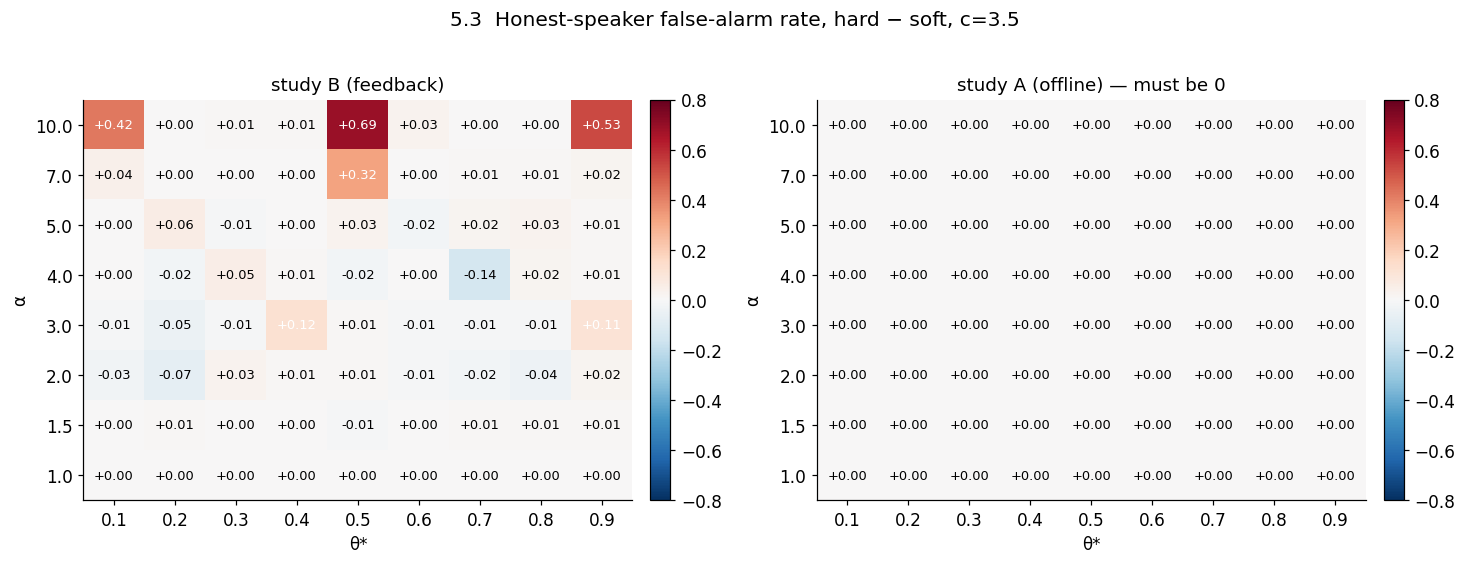

max |hard - soft| in study A (sanity, expect 0): 0.0


In [38]:
# 5.3 the pre-tau divergence that only exists in the feedback study
fa_hard = rate_by(["theta_star", "alpha"], study="B", psi_star="inf", c=FOCUS["c"], switch_type="hard")
fa_soft = rate_by(["theta_star", "alpha"], study="B", psi_star="inf", c=FOCUS["c"], switch_type="soft")
D = (pivot(fa_hard, "alpha", "theta_star", "rate") - pivot(fa_soft, "alpha", "theta_star", "rate"))
DA = (pivot(rate_by(["theta_star", "alpha"], study="A", psi_star="inf", c=FOCUS["c"], switch_type="hard"),
            "alpha", "theta_star", "rate")
      - pivot(rate_by(["theta_star", "alpha"], study="A", psi_star="inf", c=FOCUS["c"], switch_type="soft"),
              "alpha", "theta_star", "rate"))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
heat(axes[0], D.values, D.columns, D.index, "θ*", "α", "study B (feedback)",
     cmap=CMAP_DIV, vmin=-0.8, vmax=0.8, fmt="{:+.2f}")
heat(axes[1], DA.values, DA.columns, DA.index, "θ*", "α", "study A (offline) — must be 0",
     cmap=CMAP_DIV, vmin=-0.8, vmax=0.8, fmt="{:+.2f}")
fig.suptitle(f"5.3  Honest-speaker false-alarm rate, hard − soft, c={FOCUS['c']:g}"
             "", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F25_hard_minus_soft.png"))
plt.show()
print("max |hard - soft| in study A (sanity, expect 0):", float(np.abs(DA.values).max()))

## 6. Does the speaker play around the detector?

Study B records, every round before the switch, how close `Sus(t)` was to the
boundary (`margin`, always negative pre-switch) and whether the speaker took
the utterance a purely-informative or a purely-persuasive S2 would have
chosen. If the speaker were steering to stay undetected, the informative
choice would become more likely as the margin approaches zero.

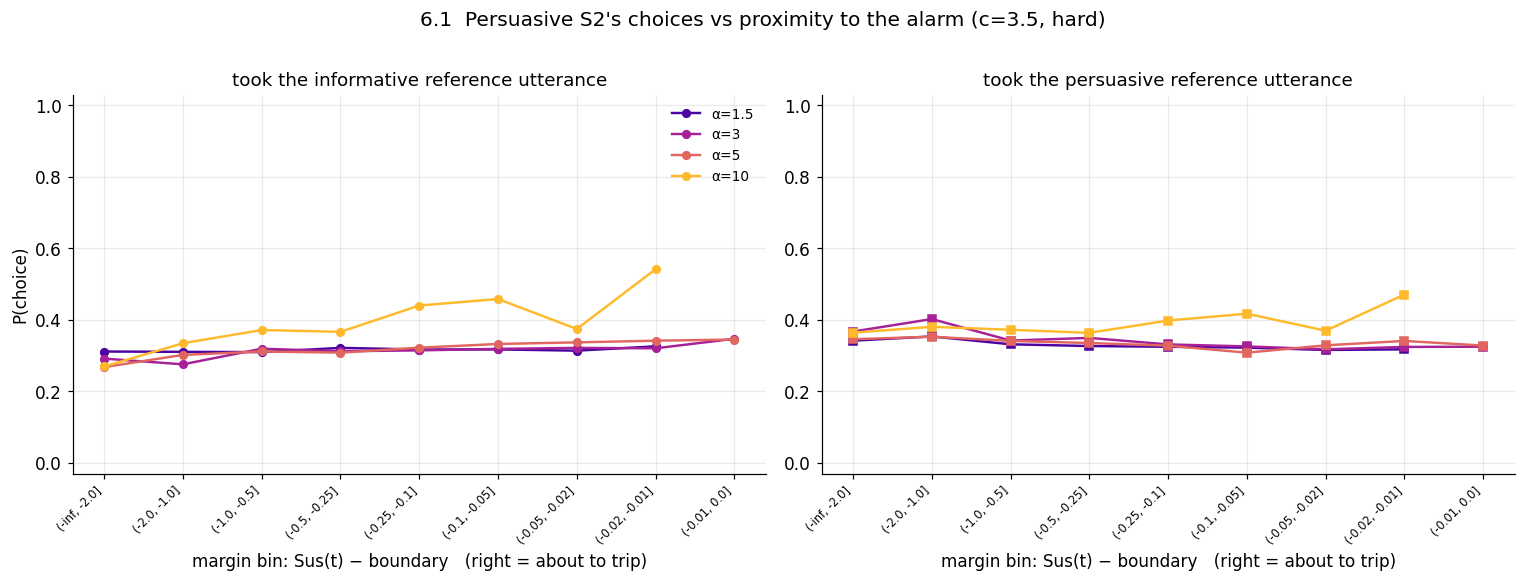

In [39]:
# 6.1 behaviour as a function of distance to the boundary
EVb = sel(EV, psi_star=["high", "low"], c=FOCUS["c"], switch_type=FOCUS["switch_type"])
order = [str(pd.Interval(left=a, right=b, closed="right"))
         for a, b in zip(META["margin_bins"][:-1], META["margin_bins"][1:])]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for a in [1.5, 3.0, 5.0, 10.0]:
    q = EVb[EVb.alpha == a].groupby("margin_bin").apply(
        lambda d: pd.Series({"wi": np.average(d.went_informative, weights=d.n),
                             "wp": np.average(d.went_persuasive, weights=d.n),
                             "n": d.n.sum()}), include_groups=False)
    q = q.reindex([o for o in order if o in q.index])
    axes[0].plot(range(len(q)), q.wi, "o-", color=ACOL[a], lw=1.6, ms=5, label=f"α={a:g}")
    axes[1].plot(range(len(q)), q.wp, "s-", color=ACOL[a], lw=1.6, ms=5, label=f"α={a:g}")
for ax, ttl in zip(axes, ["took the informative reference utterance",
                          "took the persuasive reference utterance"]):
    ax.set_xticks(range(len(order)), order, rotation=45, ha="right", fontsize=7.5)
    ax.set_xlabel("margin bin: Sus(t) − boundary   (right = about to trip)")
    ax.set_title(ttl); ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("P(choice)"); axes[0].legend(fontsize=9)
fig.suptitle(f"6.1  Persuasive S2's choices vs proximity to the alarm "
             f"(c={FOCUS['c']:g}, {FOCUS['switch_type']})", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F26_evasion_margin.png"))
plt.show()

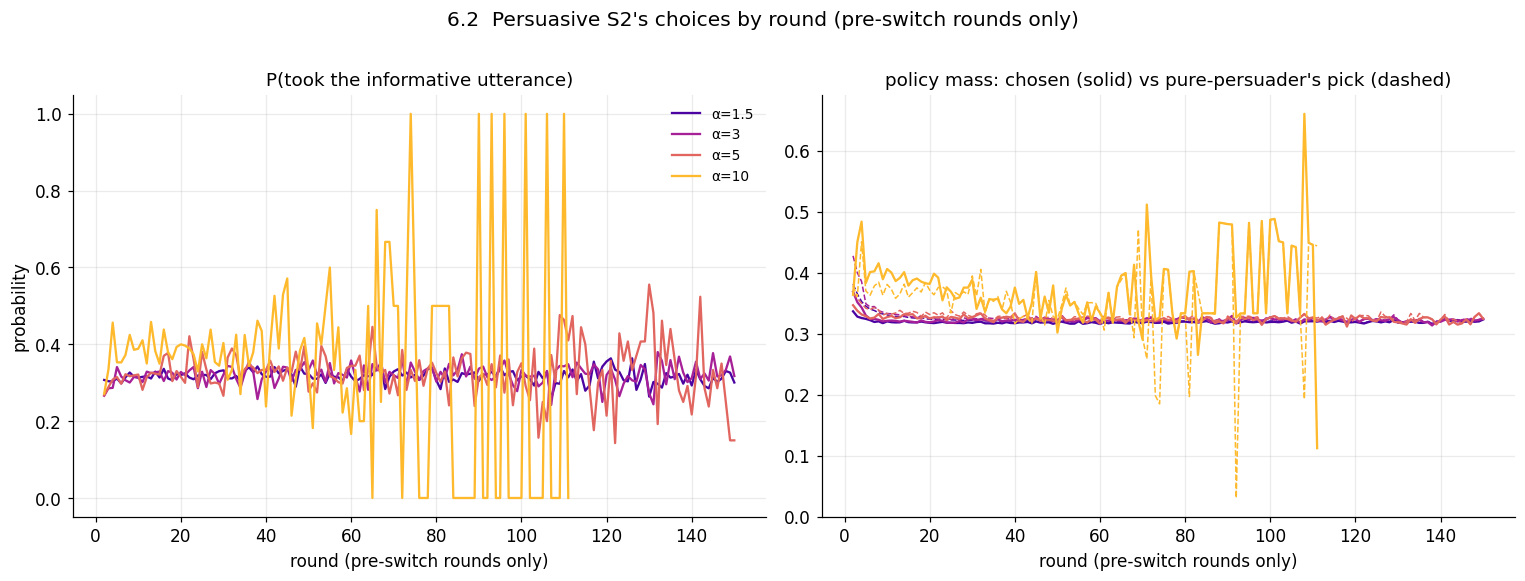

In [40]:
# 6.2 ... and over time, before the alarm
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)
for a in [1.5, 3.0, 5.0, 10.0]:
    q = (sel(EVR, psi_star=["high", "low"], alpha=a, c=FOCUS["c"], switch_type=FOCUS["switch_type"])
         .groupby("round").apply(lambda d: pd.Series({
             "wi": np.average(d.went_informative, weights=d.n),
             "pc": np.average(d.p_chosen, weights=d.n),
             "pp": np.average(d.p_pers_ref, weights=d.n)}), include_groups=False))
    axes[0].plot(q.index, q.wi, color=ACOL[a], lw=1.5, label=f"α={a:g}")
    axes[1].plot(q.index, q.pc, color=ACOL[a], lw=1.5, label=f"α={a:g}")
    axes[1].plot(q.index, q.pp, color=ACOL[a], lw=1.0, ls="--")
axes[0].set_title("P(took the informative utterance)"); axes[0].set_ylabel("probability")
axes[1].set_title("policy mass: chosen (solid) vs pure-persuader's pick (dashed)")
for ax in axes:
    ax.set_xlabel("round (pre-switch rounds only)")
axes[0].legend(fontsize=9)
fig.suptitle("6.2  Persuasive S2's choices by round (pre-switch rounds only)", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F27_evasion_rounds.png"))
plt.show()

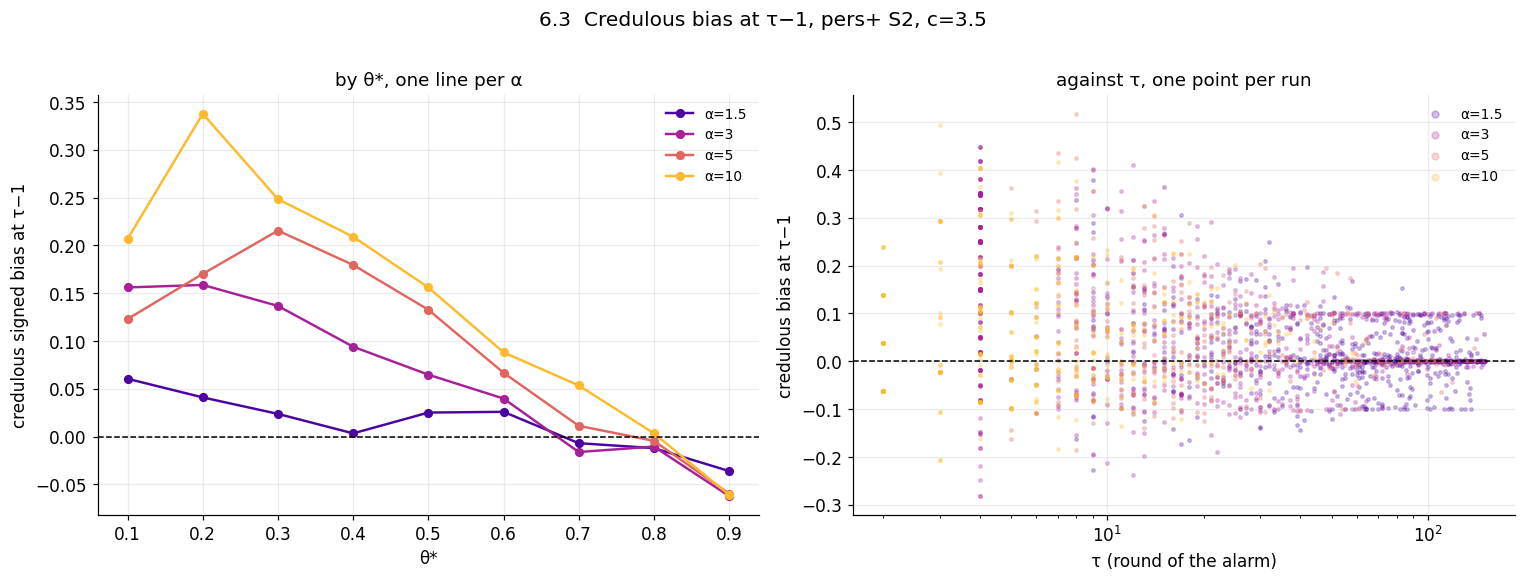

In [41]:
# 6.3 damage done before detection: the credulous belief at the moment of the alarm
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
r = sel(RU, study="B", psi_star="high", switch_type=FOCUS["switch_type"], horizon="tau_minus_1")
r = r[r.tau > 0]
for a in [1.5, 3.0, 5.0, 10.0]:
    q = r[(r.alpha == a) & (r.c == FOCUS["c"])].groupby("theta_star")["bias_cred"].mean()
    axes[0].plot(q.index, q.values, "o-", color=ACOL[a], lw=1.6, ms=5, label=f"α={a:g}")
    qq = r[(r.alpha == a) & (r.c == FOCUS["c"])]
    axes[1].scatter(qq.tau, qq.bias_cred, s=5, alpha=0.25, color=ACOL[a], label=f"α={a:g}")
axes[0].axhline(0, color="k", lw=1, ls="--")
axes[0].set_xlabel("θ*"); axes[0].set_ylabel("credulous signed bias at τ−1")
axes[0].set_title("by θ*, one line per α"); axes[0].legend(fontsize=9)
axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set_xlabel("τ (round of the alarm)"); axes[1].set_ylabel("credulous bias at τ−1")
axes[1].set_title("against τ, one point per run"); axes[1].set_xscale("log")
axes[1].legend(fontsize=9, markerscale=2)
fig.suptitle(f"6.3  Credulous bias at τ−1, pers+ S2, c={FOCUS['c']:g}", y=1.01)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F28_damage_before_tau.png"))
plt.show()

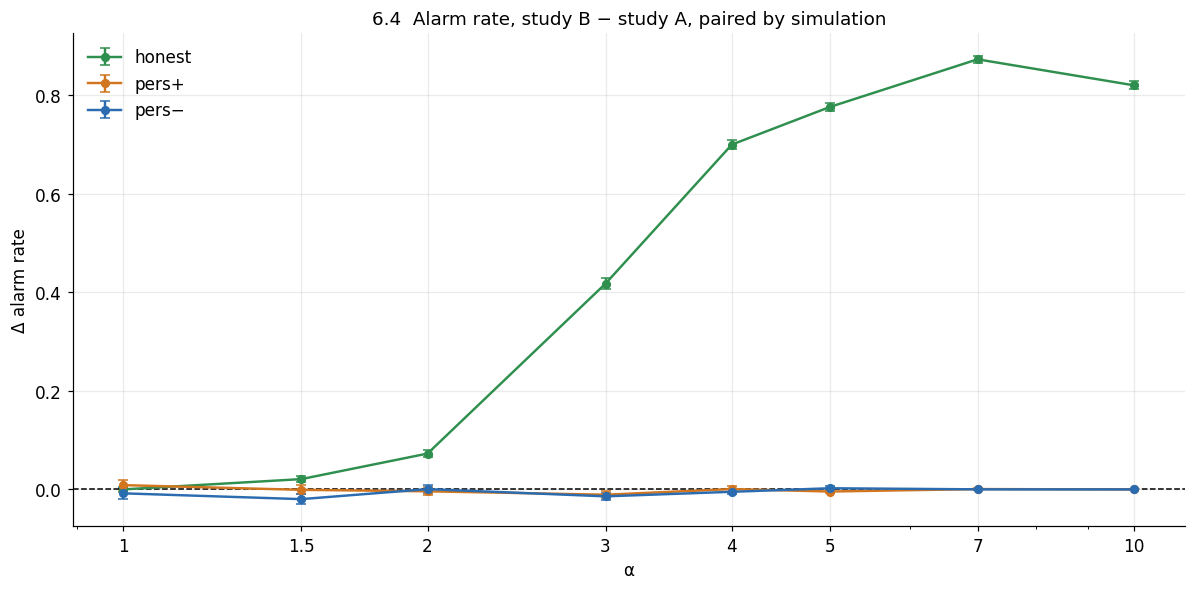

In [42]:
# 6.4 is a level-2 persuader harder to catch than a level-1 one?  Paired by
# (theta*, psi*, alpha, c, switch_type, sim) -- identical observation streams.
m = TAU[TAU.study.isin(["A", "B"])].pivot_table(
    index=["theta_star", "psi_star", "alpha", "c", "switch_type", "sim"],
    columns="study", values="switched").dropna().reset_index()
diff = (m.groupby(["psi_star", "alpha"])
          .apply(lambda d: pd.Series({"B_minus_A": (d["B"] - d["A"]).mean(),
                                      "se": (d["B"] - d["A"]).std(ddof=1) / np.sqrt(len(d))}),
                 include_groups=False).reset_index())
PSI_COL = {"inf": COL["switch"], "high": COL["cred"], "low": COL["vig"]}
fig, ax = plt.subplots(figsize=(11, 5.5))
for psi in PSIS:
    q = diff[diff.psi_star == psi].sort_values("alpha")
    ax.errorbar(q["alpha"], q["B_minus_A"], yerr=1.96 * q["se"], fmt="o-", capsize=3,
                color=PSI_COL[psi], lw=1.6, ms=5, label=PSI_LABEL[psi])
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_xscale("log"); ax.set_xticks(ALPHAS, [f"{a:g}" for a in ALPHAS])
finish(ax, "6.4  Alarm rate, study B − study A, paired by simulation"
           "",
       "α", "Δ alarm rate", save_as="F29_B_minus_A")
plt.show()

## 7. Fang's dyads at level 2 (Fvig, Fcred)

The base paper compares a credulous and a vigilant L1 against an S1. Here the
speaker is an S2 that models its actual audience correctly: **Fcred** is the
cooperative dyad (S2 ↔ credulous L1), **Fvig** the strategic one
(S2 ↔ vigilant L1). Study A on the same streams is the level-1 reference.

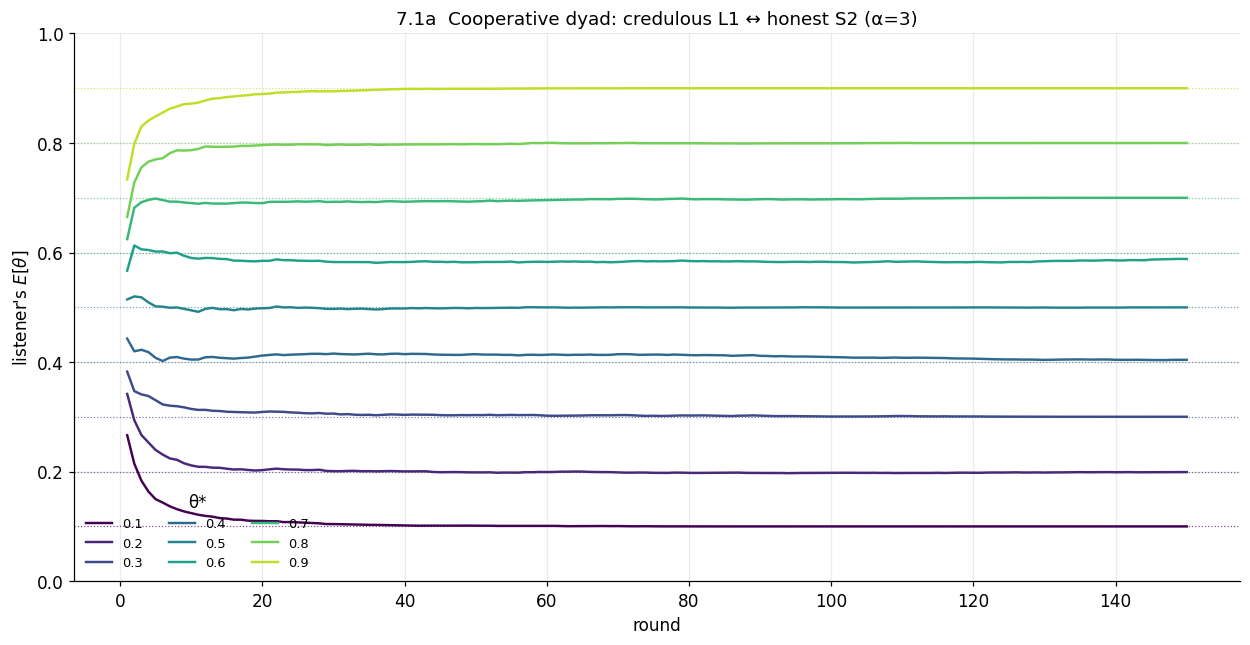

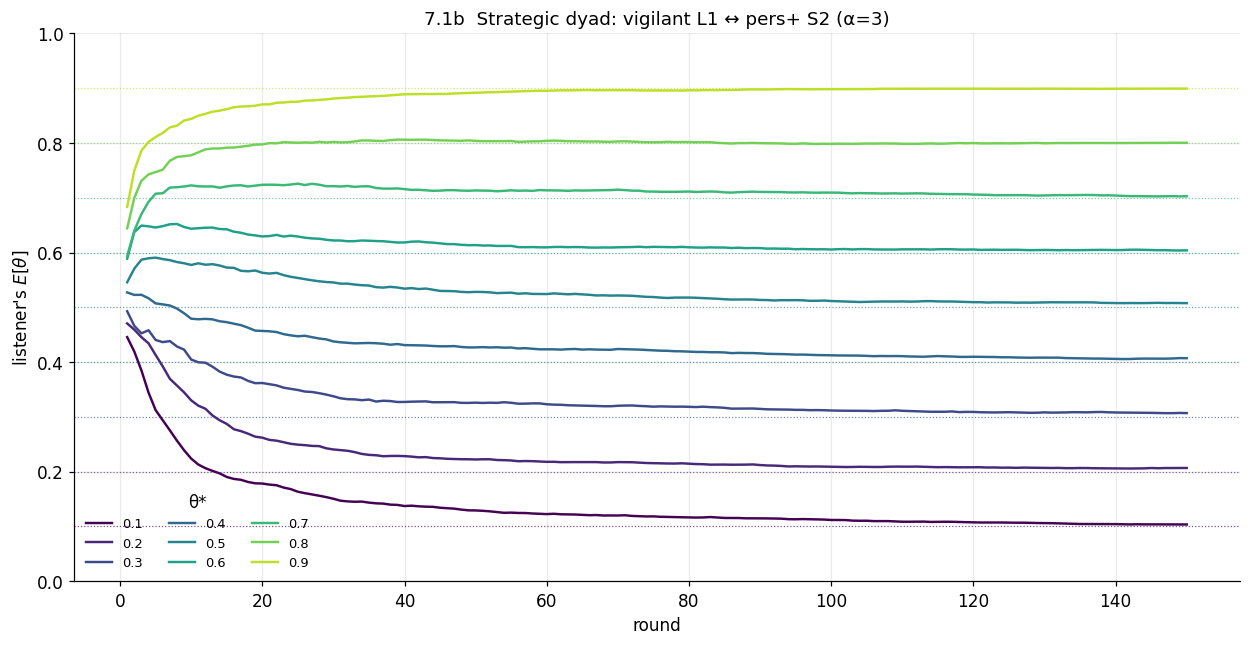

In [43]:
# 7.1 learning curves, one line per theta*, as in the paper's Figure 3
def learning_fig(study, listener, psi, alpha, title, save_as=None):
    fig, ax = plt.subplots(figsize=(11.5, 6))
    for th in THETAS:
        q = sel(RD, study=study, psi_star=psi, theta_star=th, alpha=alpha,
                c=CS[0], switch_type="hard").sort_values("round")
        ax.plot(q["round"], q[f"bias_{listener}"] + th, color=TCOL[th], lw=1.6, label=f"{th:g}")
        ax.axhline(th, color=TCOL[th], lw=0.8, ls=":", alpha=0.7)
    ax.set_ylim(0, 1)
    finish(ax, title, "round", "listener's $E[\\theta]$", ncol=3, title="θ*",
           fontsize=8.5, save_as=save_as)
    plt.show()

learning_fig("Fcred", "cred", "inf", FOCUS["alpha"],
             f"7.1a  Cooperative dyad: credulous L1 ↔ honest S2 (α={FOCUS['alpha']:g})",
             "F30_fcred_inf")
learning_fig("Fvig", "vig", "high", FOCUS["alpha"],
             f"7.1b  Strategic dyad: vigilant L1 ↔ pers+ S2 (α={FOCUS['alpha']:g})",
             "F31_fvig_high")

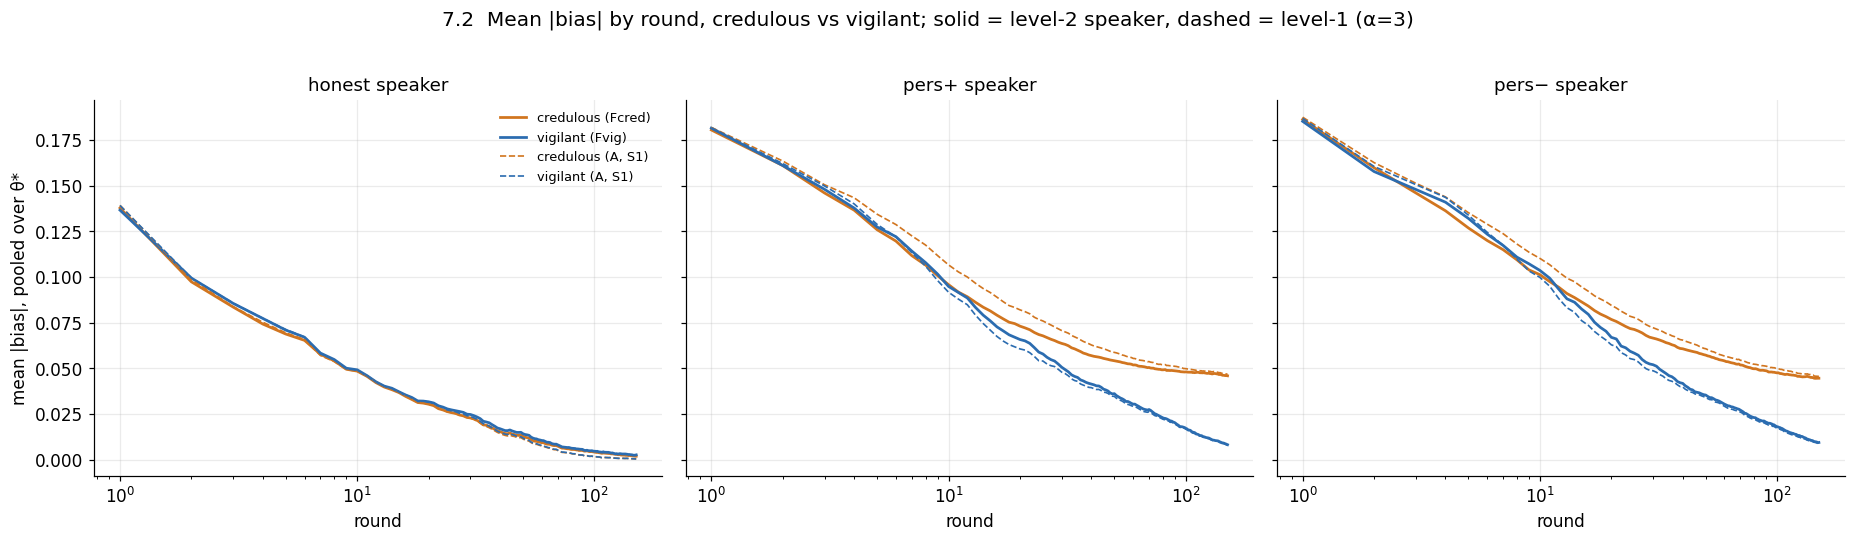

In [44]:
# 7.2 the paper's headline contrast, on identical streams: credulous vs vigilant
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for study, L in [("Fcred", "cred"), ("Fvig", "vig")]:
        q = (sel(RD, study=study, psi_star=psi, alpha=FOCUS["alpha"], c=CS[0], switch_type="hard")
             .groupby("round")[f"abias_{L}"].mean())
        ax.plot(q.index, q.values, color=COL[L], lw=1.8,
                label=f"{LISTENER_LABEL[L]} ({study})")
    q = (sel(RD, study="A", psi_star=psi, alpha=FOCUS["alpha"], c=CS[0], switch_type="hard")
         .groupby("round")[["abias_cred", "abias_vig"]].mean())
    ax.plot(q.index, q.abias_cred, color=COL["cred"], lw=1.1, ls="--", label="credulous (A, S1)")
    ax.plot(q.index, q.abias_vig, color=COL["vig"], lw=1.1, ls="--", label="vigilant (A, S1)")
    ax.set_title(f"{PSI_LABEL[psi]} speaker"); ax.set_xlabel("round"); ax.set_xscale("log")
axes[0].set_ylabel("mean |bias|, pooled over θ*"); axes[0].legend(fontsize=8.5)
fig.suptitle(f"7.2  Mean |bias| by round, credulous vs vigilant; "
             f"solid = level-2 speaker, dashed = level-1 (α={FOCUS['alpha']:g})", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F32_fang_contrast.png"))
plt.show()

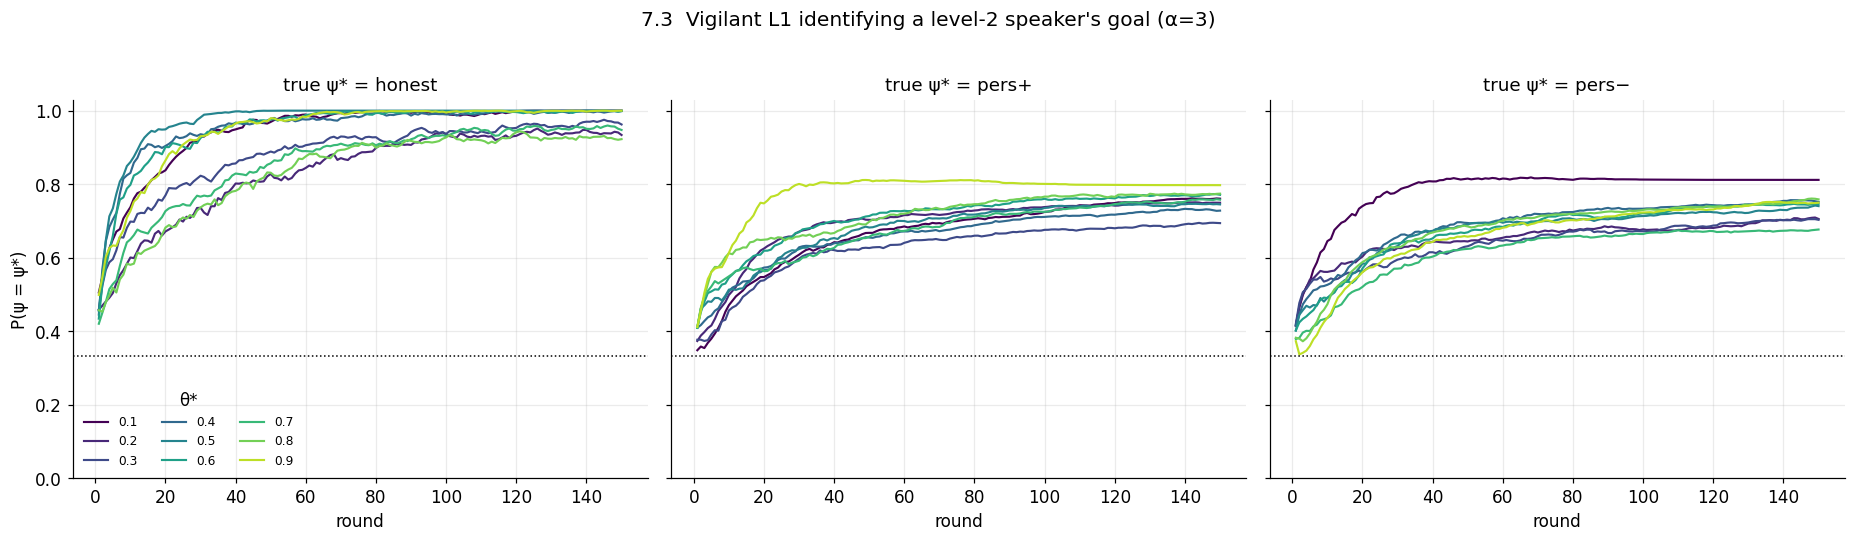

In [45]:
# 7.3 speaker-type learning by the vigilant listener (Figure 4 analogue)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, psi in zip(axes, PSIS):
    for th in THETAS:
        q = sel(RD, study="Fvig", psi_star=psi, theta_star=th, alpha=FOCUS["alpha"],
                c=CS[0], switch_type="hard").sort_values("round")
        ax.plot(q["round"], q[f"p_psi_vig_{psi}"], color=TCOL[th], lw=1.4, label=f"{th:g}")
    ax.axhline(1 / 3, color="k", lw=1, ls=":")
    ax.set_title(f"true ψ* = {PSI_LABEL[psi]}"); ax.set_xlabel("round"); ax.set_ylim(0, 1.03)
axes[0].set_ylabel("P(ψ = ψ*)"); axes[0].legend(title="θ*", ncol=3, fontsize=8)
fig.suptitle(f"7.3  Vigilant L1 identifying a level-2 speaker's goal (α={FOCUS['alpha']:g})", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F33_psi_learning_fvig.png"))
plt.show()

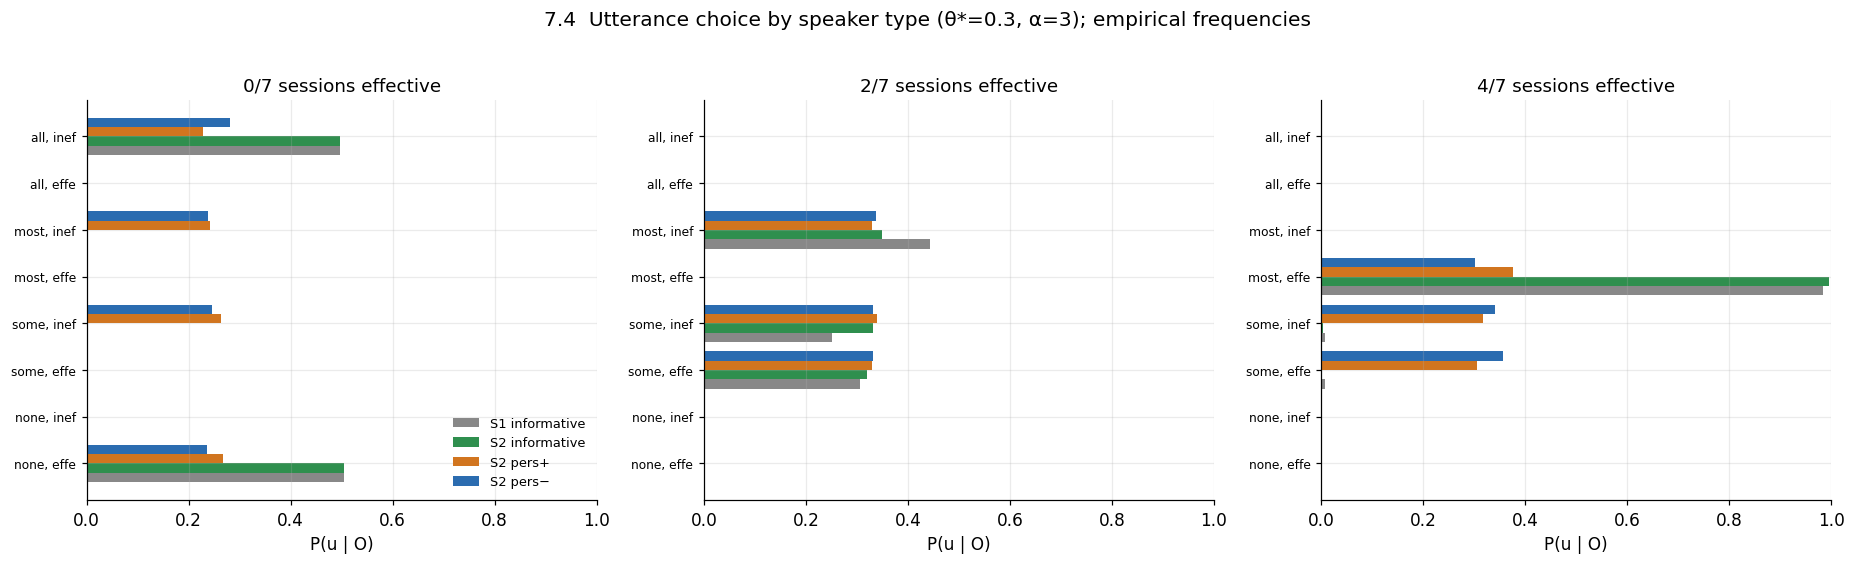

In [46]:
# 7.4 speaker policies (Figure 1 analogue) at three observations
obs_show = [0, 2, 4]
fig, axes = plt.subplots(1, len(obs_show), figsize=(17, 5), sharex=True)
srcs = [("A", "inf", "S1 informative", COL["A"]),
        ("Fcred", "inf", "S2 informative", COL["B"]),
        ("Fcred", "high", "S2 pers+", COL["cred"]),
        ("Fcred", "low", "S2 pers−", COL["vig"])]
w = 0.2
for ax, oc in zip(axes, obs_show):
    for i, (study, psi, lab, cl) in enumerate(srcs):
        P = policy_matrix(study, FOCUS["theta"], psi, FOCUS["alpha"])
        ax.barh(np.arange(8) + (i - 1.5) * w, P.loc[oc].values, w, color=cl,
                label=lab if ax is axes[0] else None)
    ax.set_yticks(range(8), UTT_LABEL, fontsize=8)
    ax.set_title(f"{oc}/7 sessions effective"); ax.set_xlabel("P(u | O)"); ax.set_xlim(0, 1)
axes[0].legend(fontsize=8.5, loc="lower right")
fig.suptitle(f"7.4  Utterance choice by speaker type (θ*={FOCUS['theta']:g}, "
             f"α={FOCUS['alpha']:g}); empirical frequencies", y=1.02)
fig.tight_layout()
if SAVE: fig.savefig(os.path.join(FIG_DIR, "F34_speaker_policies.png"))
plt.show()

## 8. Summary tables

Compact numbers for the write-up. Everything below is derived from the same
aggregates as the figures.

In [47]:
# 8.1 operating points: honest-alarm rate vs power, by alpha and c (study B)
S = OC[OC.study == "B"].copy()
S["usable"] = (S.false_alarm <= 0.10) & (S.power >= 0.60)
print("false alarm (honest S2), study B")
display(S.pivot(index="alpha", columns="c", values="false_alarm").round(3))
print("power (persuasive S2), study B")
display(S.pivot(index="alpha", columns="c", values="power").round(3))
best = S.sort_values("youden", ascending=False).head(12)
print("\nBest operating points by (power - false alarm):")
display(best[["alpha", "c", "false_alarm", "power", "youden"]].round(3).to_string(index=False))
print("\nCells meeting FA <= 0.10 and power >= 0.60:")
display(S[S.usable][["alpha", "c", "false_alarm", "power"]].round(3).to_string(index=False))

false alarm (honest S2), study B


c,2.0,3.0,3.5,4.0,5.0
alpha,,,,,
1.0,0.166,0.009,0.000,0.000,0.000
1.5,0.247,0.034,0.009,0.002,0.000
2.0,0.418,0.107,0.051,0.017,0.003
3.0,0.801,0.598,0.453,0.317,0.122
4.0,0.909,0.820,0.769,0.706,0.591
5.0,0.956,0.912,0.871,0.839,0.736
7.0,0.972,0.962,0.951,0.927,0.894
10.0,0.917,0.911,0.901,0.905,0.899


power (persuasive S2), study B


c,2.0,3.0,3.5,4.0,5.0
alpha,,,,,
1.0,0.971,0.766,0.563,0.337,0.063
1.5,0.991,0.910,0.819,0.686,0.387
2.0,0.989,0.922,0.850,0.764,0.583
3.0,0.989,0.945,0.902,0.857,0.731
4.0,0.997,0.980,0.964,0.937,0.858
5.0,0.999,0.995,0.988,0.978,0.936
7.0,1.000,0.999,0.999,0.999,0.993
10.0,1.000,1.000,1.000,1.000,1.000



Best operating points by (power - false alarm):


' alpha   c  false_alarm  power  youden\n   1.5 3.0        0.034  0.910   0.876\n   2.0 3.0        0.107  0.922   0.816\n   1.5 3.5        0.009  0.819   0.810\n   1.0 2.0        0.166  0.971   0.805\n   2.0 3.5        0.051  0.850   0.799\n   1.0 3.0        0.009  0.766   0.757\n   2.0 4.0        0.017  0.764   0.747\n   1.5 2.0        0.247  0.991   0.744\n   1.5 4.0        0.002  0.686   0.683\n   3.0 5.0        0.122  0.731   0.609\n   2.0 5.0        0.003  0.583   0.579\n   2.0 2.0        0.418  0.989   0.571'


Cells meeting FA <= 0.10 and power >= 0.60:


' alpha   c  false_alarm  power\n   1.0 3.0        0.009  0.766\n   1.5 3.0        0.034  0.910\n   1.5 3.5        0.009  0.819\n   1.5 4.0        0.002  0.686\n   2.0 3.5        0.051  0.850\n   2.0 4.0        0.017  0.764'

In [48]:
# 8.2 accuracy at round 150, pooled over theta*, per speaker type and listener
q = sel(RD, study="B", c=FOCUS["c"], switch_type=FOCUS["switch_type"])
q = q[q["round"] == 150]
acc = (q.groupby(["psi_star", "alpha"])[["abias_cred", "abias_vig", "abias_switch"]]
        .mean().round(4))
acc.index = pd.MultiIndex.from_tuples([(PSI_LABEL[p], a) for p, a in acc.index],
                                      names=["speaker", "alpha"])
print(f"Mean |bias| at round 150  (c={FOCUS['c']:g}, {FOCUS['switch_type']})")
display(acc)

Mean |bias| at round 150  (c=3.5, hard)


abias_cred  abias_vig  abias_switch
speaker alpha                                     
pers+   1.0        0.0121     0.0066        0.0085
        1.5        0.0214     0.0059        0.0074
        2.0        0.0322     0.0072        0.0074
        3.0        0.0435     0.0076        0.0077
        4.0        0.0519     0.0096        0.0096
        5.0        0.0573     0.0103        0.0103
        7.0        0.0700     0.0169        0.0169
        10.0       0.0826     0.0385        0.0385
honest  1.0        0.0020     0.0025        0.0020
        1.5        0.0029     0.0037        0.0030
        2.0        0.0024     0.0033        0.0027
        3.0        0.0020     0.0031        0.0030
        4.0        0.0014     0.0024        0.0024
        5.0        0.0007     0.0019        0.0019
        7.0        0.0004     0.0014        0.0014
        10.0       0.0003     0.0010        0.0010
pers−   1.0        0.0131     0.0070        0.0101
        1.5        0.0220     0.0074        0.0088
        2.0        0.0334     0.0083        0.0090
        3.0        0.0445     0.0093        0.0093
        4.0        0.0541     0.0107        0.0106
        5.0        0.0599     0.0125        0.0125
        7.0        0.0749     0.0205        0.0206
        10.0       0.0847     0.0420        0.0420

In [49]:
# 8.3 tau quantiles per speaker type
t = sel(TAU, study="B", switch_type=FOCUS["switch_type"], c=FOCUS["c"])
rows = []
for psi in PSIS:
    for a in ALPHAS:
        s = t[(t.psi_star == psi) & (t.alpha == a)]
        fired = s[s.tau > 0].tau
        rows.append(dict(speaker=PSI_LABEL[psi], alpha=a, rate=round(float((s.tau > 0).mean()), 3),
                         tau_q25=fired.quantile(.25), tau_med=fired.median(), tau_q75=fired.quantile(.75)))
display(pd.DataFrame(rows).pivot(index="alpha", columns="speaker",
                                 values=["rate", "tau_med"]).round(2))

rate             tau_med             
speaker honest pers+ pers−  honest  pers+ pers−
alpha                                          
1.0       0.00  0.56  0.55     NaN  100.0  95.0
1.5       0.01  0.82  0.82    55.5   68.5  71.0
2.0       0.05  0.85  0.85    88.0   42.5  42.5
3.0       0.46  0.90  0.92    83.0   21.0  20.0
4.0       0.76  0.95  0.97    47.0    8.0   9.0
5.0       0.88  0.99  0.99    33.0    1.0   1.0
7.0       0.97  1.00  1.00    21.0    1.0   1.0
10.0      0.99  1.00  1.00    16.0    1.0   1.0

---

### Reproducing / extending

* `python experiments/switching/aggregate.py` rebuilds every table in
  `results/switching/agg/` from the raw shards (~1 min on 16 workers).
* `FOCUS` in §0 re-aims most single-configuration figures; `SAVE = True`
  writes every figure to `results/switching/figures/`.
* `load_cell(study, theta_star, psi_star, alpha, c=..., switch_type=...)`
  returns raw per-round rows when an aggregate is not enough.